# 🏭 Risk Prediction in Supply Chain Finance — Adaptive Feature Selection + 3-Level Stacking Ensemble
## End-Semester Project · Polish Companies Bankruptcy Dataset
### Base Papers: Zieba et al. (2016) + Barboza et al. (2017)

**Key Innovations in this Notebook:**
1. **Per-year Adaptive Feature Selection** via SHAP (fixed API — handles 3-D output correctly)
2. **12 SCF-domain Composite Features** — Altman-Z, Zmijewski, Springate, CCC, DSS, PCI …
3. **3-Level Stacking Ensemble** — Level 0 (XGB+RF+LGBM+LR+GBC) → Level 1 (meta-LR / meta-XGB) → Level 2 (threshold opt.)
4. **Class-Imbalance** — SMOTE + cost-sensitive weights + F1-optimal threshold
5. **Checkpoint / Resume** — each year saved so long runs are safe
6. **Top-50 Risk Register** per year with CRITICAL / HIGH / MEDIUM / WATCH tiers


## 0 · Installs & Imports

In [ ]:
!pip install imbalanced-learn xgboost lightgbm scikit-learn matplotlib seaborn \
             pandas numpy scipy joblib optuna shap -q

import warnings, os, zipfile, json, time, itertools
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from matplotlib.patches import Patch
from matplotlib.lines   import Line2D

from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.preprocessing     import RobustScaler
from sklearn.impute            import SimpleImputer
from sklearn.base              import clone
from sklearn.metrics           import (roc_auc_score, f1_score, recall_score,
                                        precision_score, accuracy_score,
                                        average_precision_score,
                                        confusion_matrix, roc_curve,
                                        precision_recall_curve, fbeta_score)
from sklearn.model_selection   import StratifiedKFold, cross_val_score, train_test_split
from sklearn.feature_selection import mutual_info_classif

from scipy.stats  import spearmanr, mannwhitneyu
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
import shap
print(f'  SHAP version: {shap.__version__}  (3-D output handled correctly)')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import joblib

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
PALETTE = ['#1a6faf','#d64e12','#2ca02c','#9467bd','#e377c2','#8c564b','#bcbd22']
print('✅ All imports successful')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.5 MB/s eta 0:00:00
  SHAP version: 0.51.0  (3-D output handled correctly)
✅ All imports successful


## 1 · Data Loading

In [ ]:
POSSIBLE = [
    '/content/polish+companies+bankruptcy+data.zip',
    '/content/polish_companies_bankruptcy_data.zip',
    '/content/drive/MyDrive/polish_companies_bankruptcy_data.zip',
    'polish_companies_bankruptcy_data.zip',
    'polish+companies+bankruptcy+data.zip',
]
ZIP_PATH = next((p for p in POSSIBLE if os.path.exists(p)), None)
if ZIP_PATH is None:
    try:
        from google.colab import files
        print('⬆️  Upload polish_companies_bankruptcy_data.zip')
        ZIP_PATH = list(files.upload().keys())[0]
    except:
        raise FileNotFoundError('Zip not found — upload to /content/')

print(f'✅ Found: {ZIP_PATH}')

import tempfile
EXTRACT_DIR = os.path.join(tempfile.gettempdir(), 'polish_bk')
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

def parse_arff(path):
    rows, attrs, in_data = [], [], False
    with open(path, encoding='utf-8', errors='replace') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'): continue
            up = line.upper()
            if up.startswith('@ATTRIBUTE'):
                attrs.append(line.split()[1])
            elif up.startswith('@DATA'):
                in_data = True
            elif in_data:
                vals = []
                for v in line.split(','):
                    try:    vals.append(float(v.strip()))
                    except: vals.append(np.nan)
                rows.append(vals)
    df = pd.DataFrame(rows, columns=attrs)
    if 'class' in df.columns:
        df = df.rename(columns={'class': 'target'})
    df['target'] = df['target'].astype(int)
    return df

years_raw = {}
for yr in range(1, 6):
    for root, _, files_list in os.walk(EXTRACT_DIR):
        for fn in files_list:
            if fn.endswith('.arff') and f'{yr}year' in fn.lower():
                years_raw[yr] = parse_arff(os.path.join(root, fn))
                print(f'  Year {yr}: {years_raw[yr].shape} | Bankrupt: {years_raw[yr].target.sum():,}')

FEAT_NAMES_RAW = [c for c in years_raw[1].columns if c != 'target']
N_RAW = len(FEAT_NAMES_RAW)
print(f'\n✅ Dataset loaded: 5 years, {N_RAW} raw features')


✅ Found: /content/polish+companies+bankruptcy+data.zip
  Year 1: (7027, 65) | Bankrupt: 271
  Year 2: (10173, 65) | Bankrupt: 400
  Year 3: (10503, 65) | Bankrupt: 495
  Year 4: (9792, 65) | Bankrupt: 515
  Year 5: (5910, 65) | Bankrupt: 410

✅ Dataset loaded: 5 years, 64 raw features


## 2 · Exploratory Data Analysis

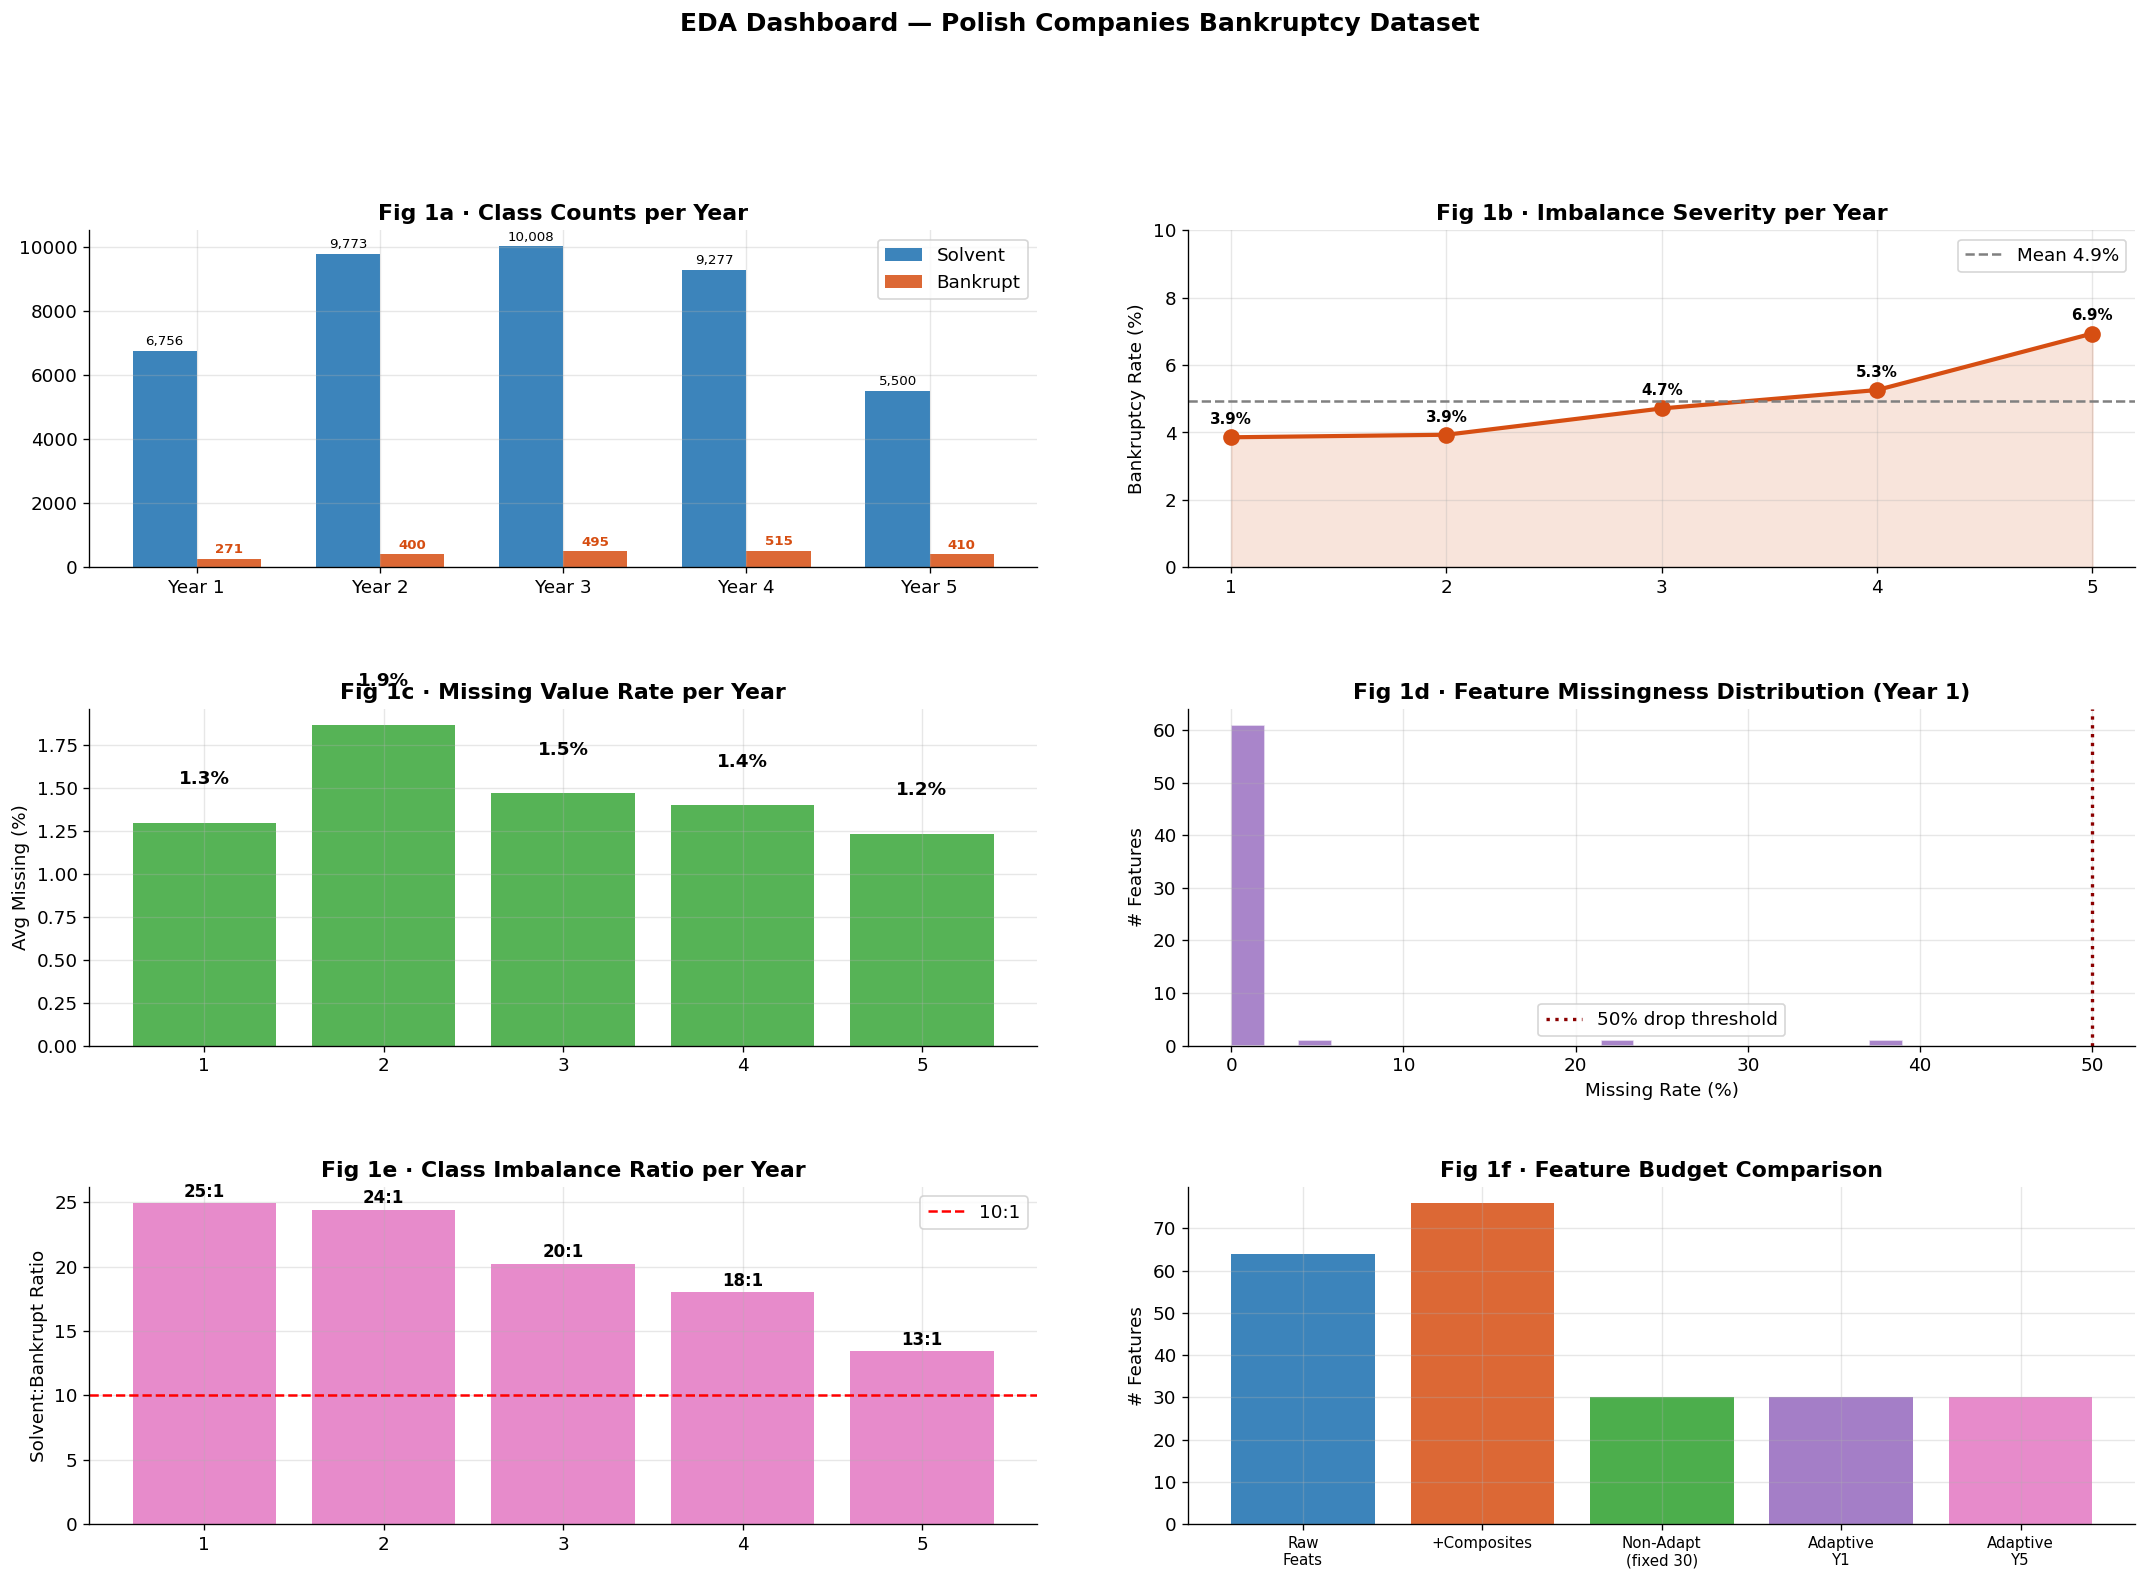


📊 Dataset Summary:
  Total companies: 43,405  |  Bankrupt: 2,091  |  Mean rate: 4.94%
  Max imbalance: 25:1 (Year 1)


In [ ]:
# ── Fig 1: Dataset Overview Dashboard ─────────────────────────────────────────
fig = plt.figure(figsize=(22, 14))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.42, wspace=0.38)

yr_list   = list(range(1, 6))
totals    = [years_raw[y].shape[0]           for y in yr_list]
bankrupts = [int(years_raw[y].target.sum())  for y in yr_list]
solvents  = [t - b for t, b in zip(totals, bankrupts)]
bk_rates  = [b/t*100 for b, t in zip(bankrupts, totals)]

ax = fig.add_subplot(gs[0, :2])
x, w = np.arange(5), 0.35
b1 = ax.bar(x - w/2, solvents,  w, label='Solvent',  color=PALETTE[0], alpha=0.85)
b2 = ax.bar(x + w/2, bankrupts, w, label='Bankrupt', color=PALETTE[1], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'Year {y}' for y in yr_list])
ax.set_title('Fig 1a · Class Counts per Year', fontweight='bold'); ax.legend()
for bar, val in zip(b1, solvents):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80, f'{val:,}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(b2, bankrupts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80, f'{val:,}', ha='center', va='bottom', fontsize=8, color=PALETTE[1], fontweight='bold')

ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(yr_list, bk_rates, 'o-', color=PALETTE[1], lw=2.5, ms=9)
ax2.fill_between(yr_list, bk_rates, alpha=0.15, color=PALETTE[1])
ax2.axhline(np.mean(bk_rates), ls='--', color='gray', lw=1.5, label=f'Mean {np.mean(bk_rates):.1f}%')
ax2.set_xticks(yr_list); ax2.set_ylabel('Bankruptcy Rate (%)'); ax2.set_ylim(0,10)
ax2.set_title('Fig 1b · Imbalance Severity per Year', fontweight='bold'); ax2.legend()
for y, r in zip(yr_list, bk_rates):
    ax2.text(y, r+0.3, f'{r:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3 = fig.add_subplot(gs[1, :2])
miss = [years_raw[y].drop(columns='target').isna().mean().mean()*100 for y in yr_list]
ax3.bar(yr_list, miss, color=PALETTE[2], alpha=0.8)
ax3.set_xticks(yr_list); ax3.set_ylabel('Avg Missing (%)')
ax3.set_title('Fig 1c · Missing Value Rate per Year', fontweight='bold')
for y, p in zip(yr_list, miss):
    ax3.text(y, p+0.2, f'{p:.1f}%', ha='center', va='bottom', fontweight='bold')

ax4 = fig.add_subplot(gs[1, 2:])
df1_miss = (years_raw[1].drop(columns='target').isna().mean()*100).sort_values(ascending=False)
ax4.hist(df1_miss.values, bins=20, color=PALETTE[3], alpha=0.8, edgecolor='white')
ax4.axvline(50, color='darkred', ls=':', lw=2, label='50% drop threshold')
ax4.set_xlabel('Missing Rate (%)'); ax4.set_ylabel('# Features')
ax4.set_title('Fig 1d · Feature Missingness Distribution (Year 1)', fontweight='bold'); ax4.legend()

ax5 = fig.add_subplot(gs[2, :2])
ratios = [s/b for s, b in zip(solvents, bankrupts)]
ax5.bar(yr_list, ratios, color=PALETTE[4], alpha=0.85)
ax5.axhline(10, color='red', ls='--', lw=1.5, label='10:1')
ax5.set_xticks(yr_list); ax5.set_ylabel('Solvent:Bankrupt Ratio')
ax5.set_title('Fig 1e · Class Imbalance Ratio per Year', fontweight='bold'); ax5.legend()
for y, r in zip(yr_list, ratios):
    ax5.text(y, r+0.2, f'{r:.0f}:1', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax6 = fig.add_subplot(gs[2, 2:])
ax6.bar(range(5), [N_RAW, N_RAW+12, 30, 30, 30], color=PALETTE[:5], alpha=0.85)
ax6.set_xticks(range(5))
ax6.set_xticklabels(['Raw\nFeats', '+Composites', 'Non-Adapt\n(fixed 30)', 'Adaptive\nY1','Adaptive\nY5'], fontsize=9)
ax6.set_ylabel('# Features'); ax6.set_title('Fig 1f · Feature Budget Comparison', fontweight='bold')

fig.suptitle('EDA Dashboard — Polish Companies Bankruptcy Dataset', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_eda_overview.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\n📊 Dataset Summary:')
print(f'  Total companies: {sum(totals):,}  |  Bankrupt: {sum(bankrupts):,}  |  Mean rate: {np.mean(bk_rates):.2f}%')
print(f'  Max imbalance: {max(ratios):.0f}:1 (Year {yr_list[ratios.index(max(ratios))]})')


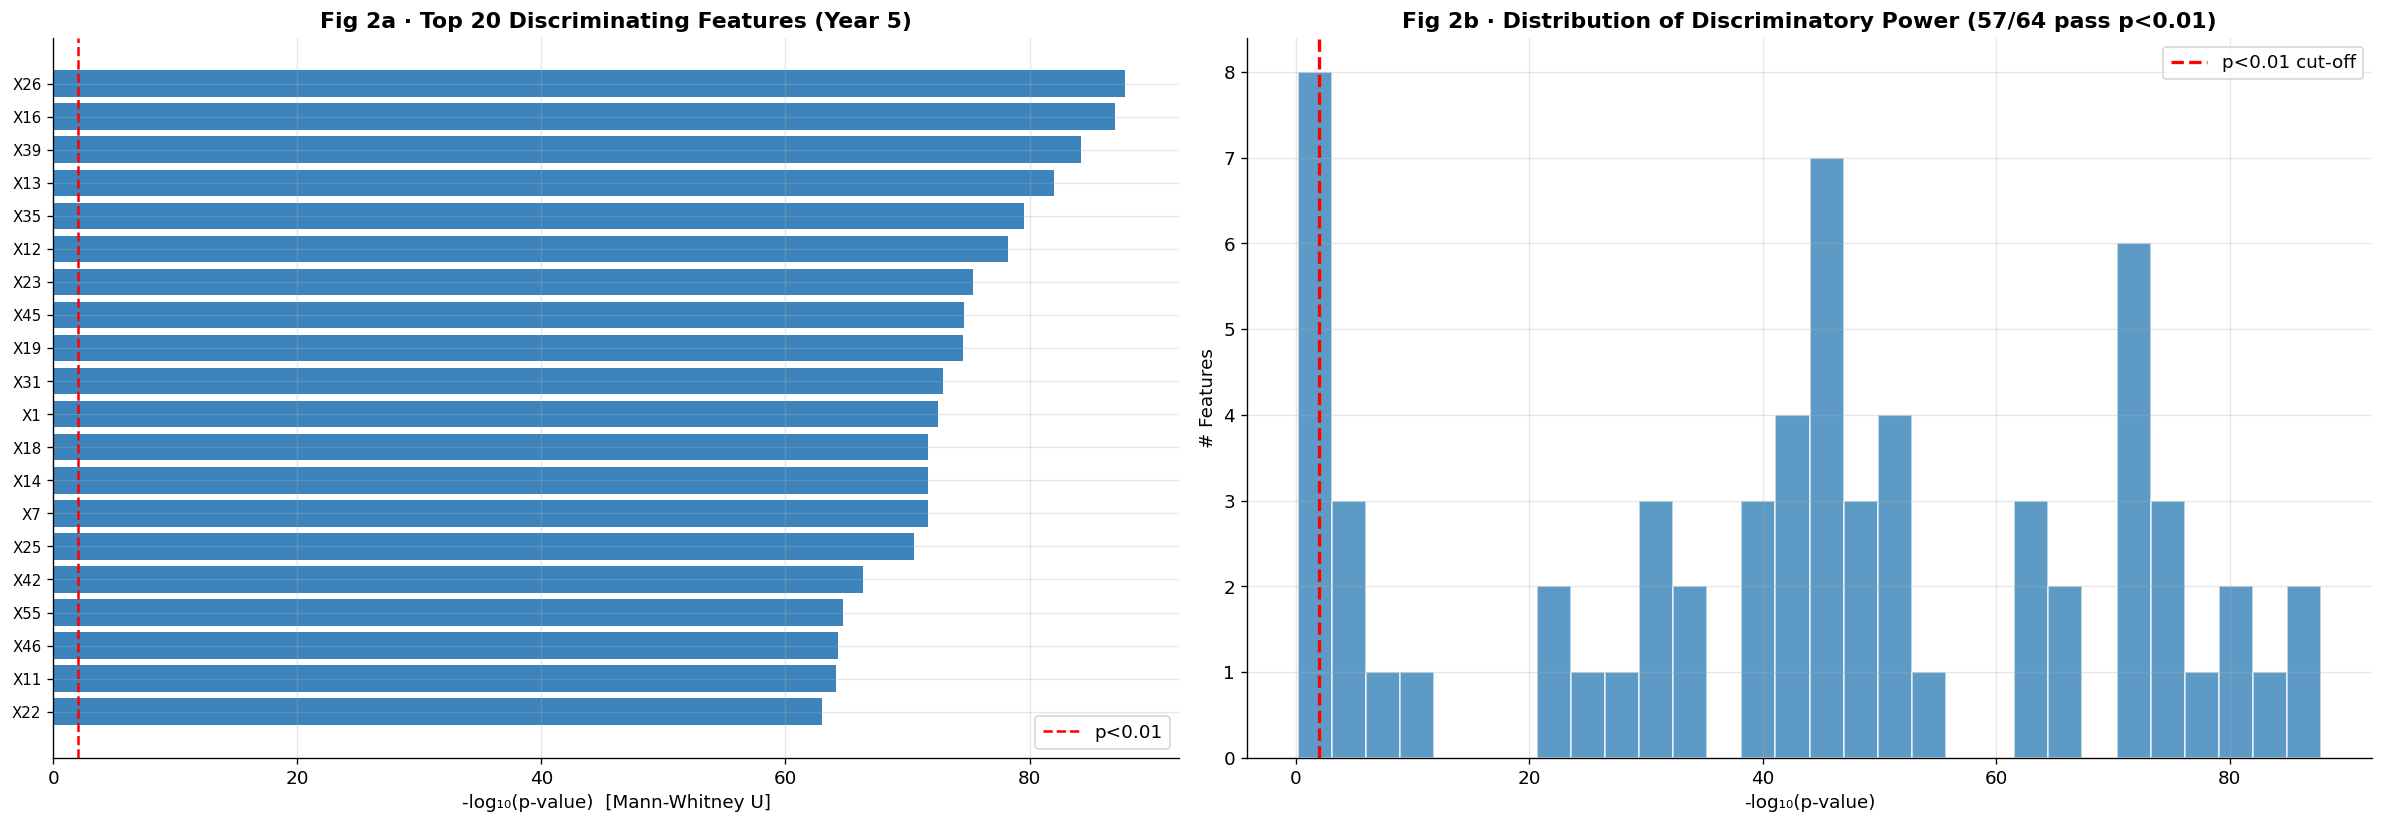

In [ ]:
# ── Fig 2: Feature Discriminatory Power (Mann-Whitney U) ──────────────────────
df5   = years_raw[5].copy()
feats = [c for c in df5.columns if c != 'target']

mw_scores = {}
for f in feats:
    vals = df5[f].dropna()
    idx  = df5.loc[vals.index, 'target']
    bk, sl = vals[idx==1], vals[idx==0]
    if len(bk) > 5 and len(sl) > 5:
        _, pval = mannwhitneyu(bk, sl, alternative='two-sided')
        mw_scores[f] = -np.log10(pval + 1e-300)

mw_df = pd.Series(mw_scores).sort_values(ascending=False)
top20 = mw_df.head(20)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
ax = axes[0]
ax.barh(range(20), top20.values[::-1], color=PALETTE[0], alpha=0.85)
ax.set_yticks(range(20)); ax.set_yticklabels([f.replace('Attr','X') for f in top20.index[::-1]], fontsize=9)
ax.axvline(2, ls='--', color='red', lw=1.5, label='p<0.01')
ax.set_xlabel('-log₁₀(p-value)  [Mann-Whitney U]')
ax.set_title('Fig 2a · Top 20 Discriminating Features (Year 5)', fontweight='bold'); ax.legend()

ax2 = axes[1]
ax2.hist(list(mw_scores.values()), bins=30, color=PALETTE[0], alpha=0.7, edgecolor='white')
ax2.axvline(2, ls='--', color='red', lw=2, label='p<0.01 cut-off')
high = sum(v > 2 for v in mw_scores.values())
ax2.set_xlabel('-log₁₀(p-value)'); ax2.set_ylabel('# Features')
ax2.set_title(f'Fig 2b · Distribution of Discriminatory Power ({high}/{len(mw_scores)} pass p<0.01)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('fig2_feature_discriminatory_power.png', dpi=130, bbox_inches='tight')
plt.show()


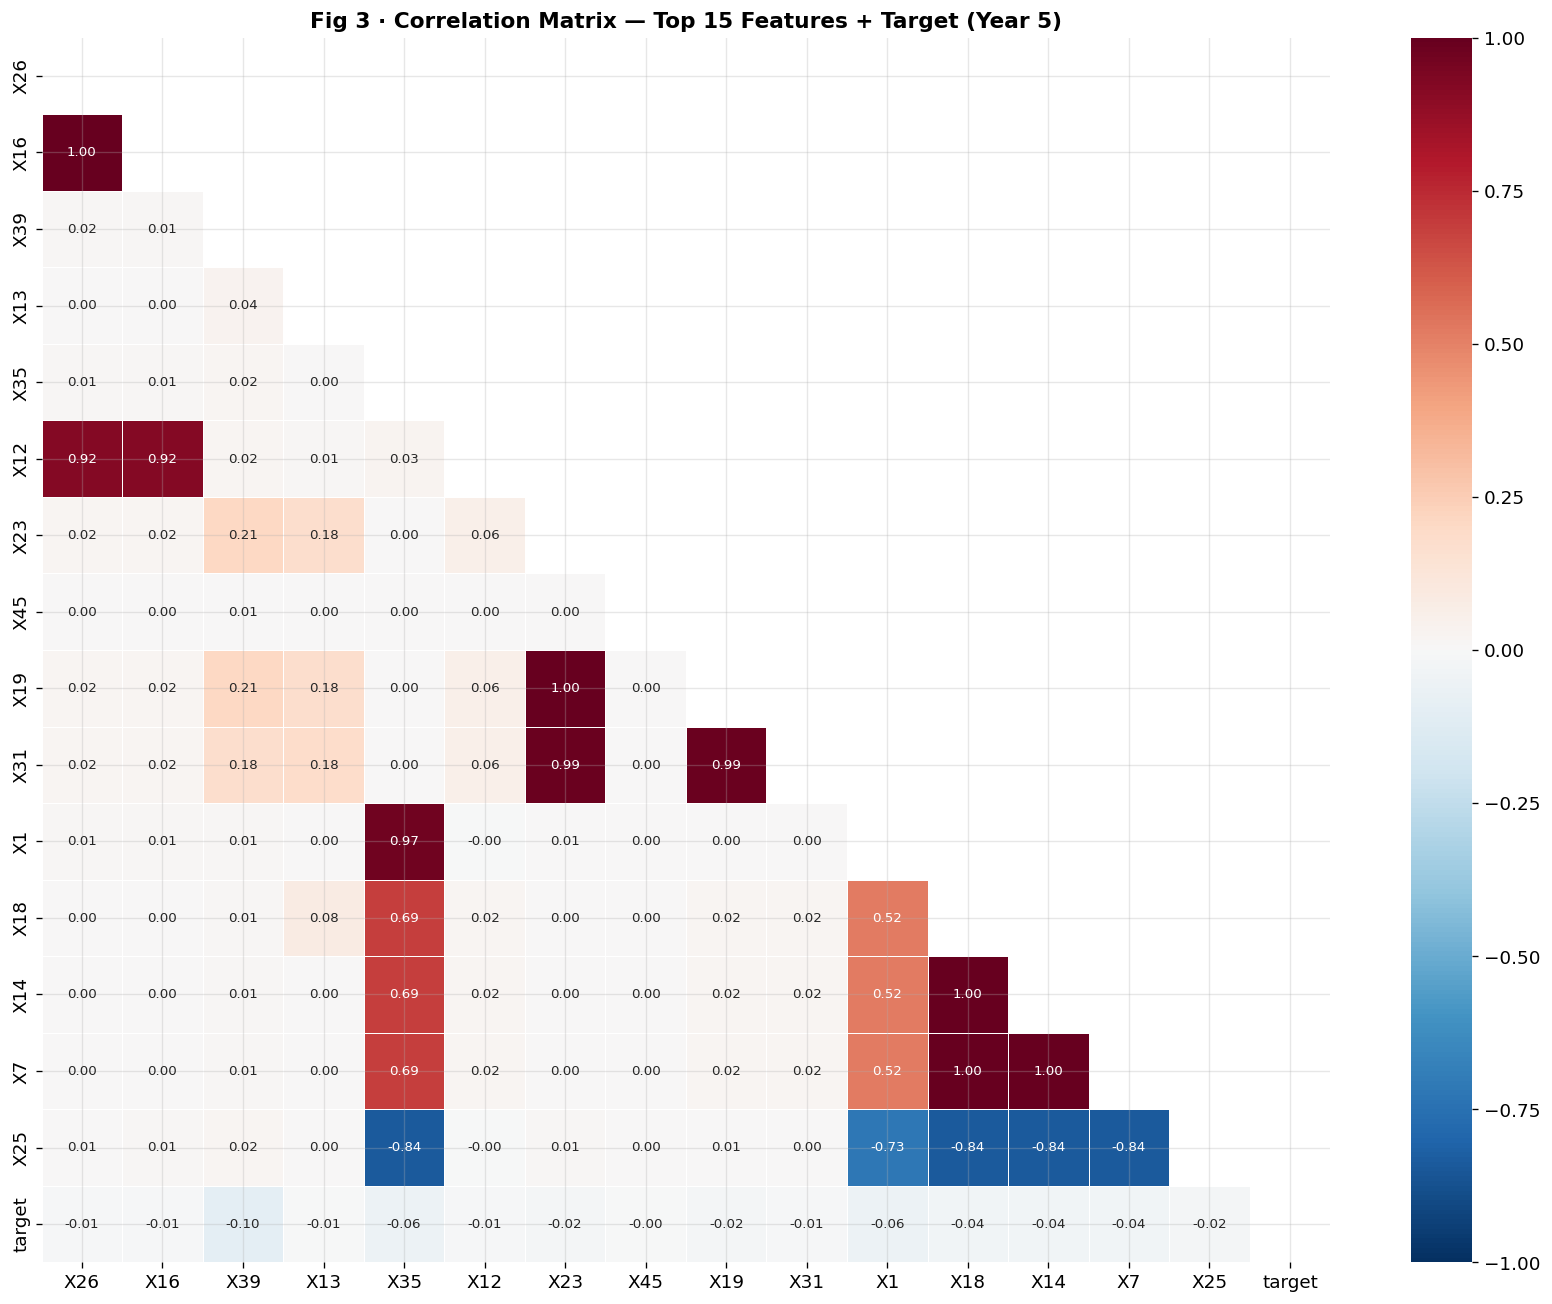

In [ ]:
# ── Fig 3: Correlation Heatmap ─────────────────────────────────────────────────
top_feats_corr = list(top20.index[:15]) + ['target']
df_corr = df5[top_feats_corr].copy()
df_corr.columns = [c.replace('Attr','X') for c in df_corr.columns]

corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Fig 3 · Correlation Matrix — Top 15 Features + Target (Year 5)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_correlation.png', dpi=130, bbox_inches='tight')
plt.show()


## 3 · Preprocessing Pipeline
- Median imputation → Winsorize ±5σ (RobustScaler units) → RobustScaler  
- Applied **fit** on training split only; **transform** on test split to prevent leakage


In [ ]:
def preprocess(df, imputer=None, scaler=None, fit=False):
    """Median-impute → RobustScale → clip to [-5, 5]."""
    X = df.drop(columns='target')
    y = df['target'].copy()
    if fit:
        imp = SimpleImputer(strategy='median')
        X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)
        sc  = RobustScaler()
        X_sc = pd.DataFrame(sc.fit_transform(X_imp), columns=X.columns, index=X.index)
    else:
        X_imp = pd.DataFrame(imputer.transform(X), columns=X.columns, index=X.index)
        X_sc  = pd.DataFrame(scaler.transform(X_imp), columns=X.columns, index=X.index)
        imp, sc = imputer, scaler
    X_sc = X_sc.clip(-5, 5)
    return X_sc, y, imp, sc

# Pre-process all years (fit on each year independently for the pipeline)
years_processed = {}
for yr in range(1, 6):
    X_sc, y, imp, sc = preprocess(years_raw[yr], fit=True)
    years_processed[yr] = {'X': X_sc, 'y': y, 'imp': imp, 'sc': sc}
    print(f'Year {yr}: {X_sc.shape}  Bankrupt: {y.sum():,}  Features: {X_sc.shape[1]}')

print('\n✅ All years preprocessed')


Year 1: (7027, 64)  Bankrupt: 271  Features: 64
Year 2: (10173, 64)  Bankrupt: 400  Features: 64
Year 3: (10503, 64)  Bankrupt: 495  Features: 64
Year 4: (9792, 64)  Bankrupt: 515  Features: 64
Year 5: (5910, 64)  Bankrupt: 410  Features: 64

✅ All years preprocessed


## 4 · Composite Feature Engineering (12 SCF-domain Indicators)
Full 12-feature set from the SCF literature + domain knowledge.


In [ ]:
COMPOSITE_COLS = [
    'Z_altman','Z_zmijewski','S_springate','G_grover','T_taffler',
    'PCI','LSI','CCC','DSS','CDS','SCFNI','LDZ'
]
COMP_ALIAS = {
    'Z_altman':'Altman Z','Z_zmijewski':'Zmijewski','S_springate':'Springate',
    'G_grover':'Grover G','T_taffler':'Taffler Z','PCI':'Profit.Collapse',
    'LSI':'Liq.Stress','CCC':'CashConv.Cycle','DSS':'Debt.Service',
    'CDS':'Distress.Count','SCFNI':'SCF.Finance.Need','LDZ':'Lev.Danger.Zone',
}

def add_composites(X_df):
    """Append 12 composite SCF features to a DataFrame."""
    X = X_df.copy()
    eps = 1e-9
    def A(n):
        col = f'Attr{n}'
        return X[col].values.astype(float) if col in X.columns else np.zeros(len(X))
    def sdiv(a, b):
        return np.where(np.abs(b) < eps, 0.0, a / (b + eps))

    X['Z_altman']    = 1.2*A(3) + 1.4*A(6) + 3.3*A(7) + 0.6*A(8) + 1.0*A(9)
    X['Z_zmijewski'] = -4.336 - 4.513*A(1) + 5.679*A(2) + 0.004*A(4)
    X['S_springate'] = 1.03*A(3) + 3.07*A(22) + 0.66*A(12) + 0.40*A(9)
    X['G_grover']    = 1.650*A(3) + 3.404*A(7) - 0.016*sdiv(A(1), A(2)) + 0.057
    X['T_taffler']   = 0.53*A(12) + 0.13*A(4) + 0.18*A(51) + 0.16*A(21)

    prod  = A(1)*A(22)*A(35)
    denom = np.abs(A(1)) + np.abs(A(22)) + np.abs(A(35)) + eps
    X['PCI'] = prod / denom

    liq_min   = np.minimum(np.minimum(A(4), A(40)), A(46))
    X['LSI']  = liq_min * sdiv(1.0, 1 + A(51))
    X['CCC']  = A(20) + A(44) - A(32)
    X['DSS']  = (A(16) + A(26)) / 2.0
    X['CDS']  = ((A(1)<0).astype(float) + (A(3)<0).astype(float) +
                 (A(4)<1).astype(float) + (A(10)<0.1).astype(float) +
                 (A(35)<0).astype(float) + (A(16)<0.05).astype(float))
    X['SCFNI'] = sdiv(A(20)+A(44)-A(32), A(9))
    X['LDZ']   = A(2) * (1 - A(10)) * np.where(A(1) < 0, 1.0, 0.0)

    for col in COMPOSITE_COLS:
        s = X[col].replace([np.inf,-np.inf], np.nan)
        lo, hi = s.quantile(0.01), s.quantile(0.99)
        X[col] = s.clip(lo, hi).fillna(s.median())
    return X

# Build augmented datasets (raw features + composites)
years_aug = {}
for yr in range(1, 6):
    X_aug = add_composites(years_processed[yr]['X'])
    years_aug[yr] = {'X': X_aug, 'y': years_processed[yr]['y']}

print(f'Features after composites: {years_aug[1]["X"].shape[1]} ({len(COMPOSITE_COLS)} new)')
print(f'Composite features: {COMPOSITE_COLS}')


Features after composites: 76 (12 new)
Composite features: ['Z_altman', 'Z_zmijewski', 'S_springate', 'G_grover', 'T_taffler', 'PCI', 'LSI', 'CCC', 'DSS', 'CDS', 'SCFNI', 'LDZ']


## 5 · Spatial Separation Analysis
Quantify how well-separated bankrupt vs solvent companies are in feature space,
before and after adding composite features.


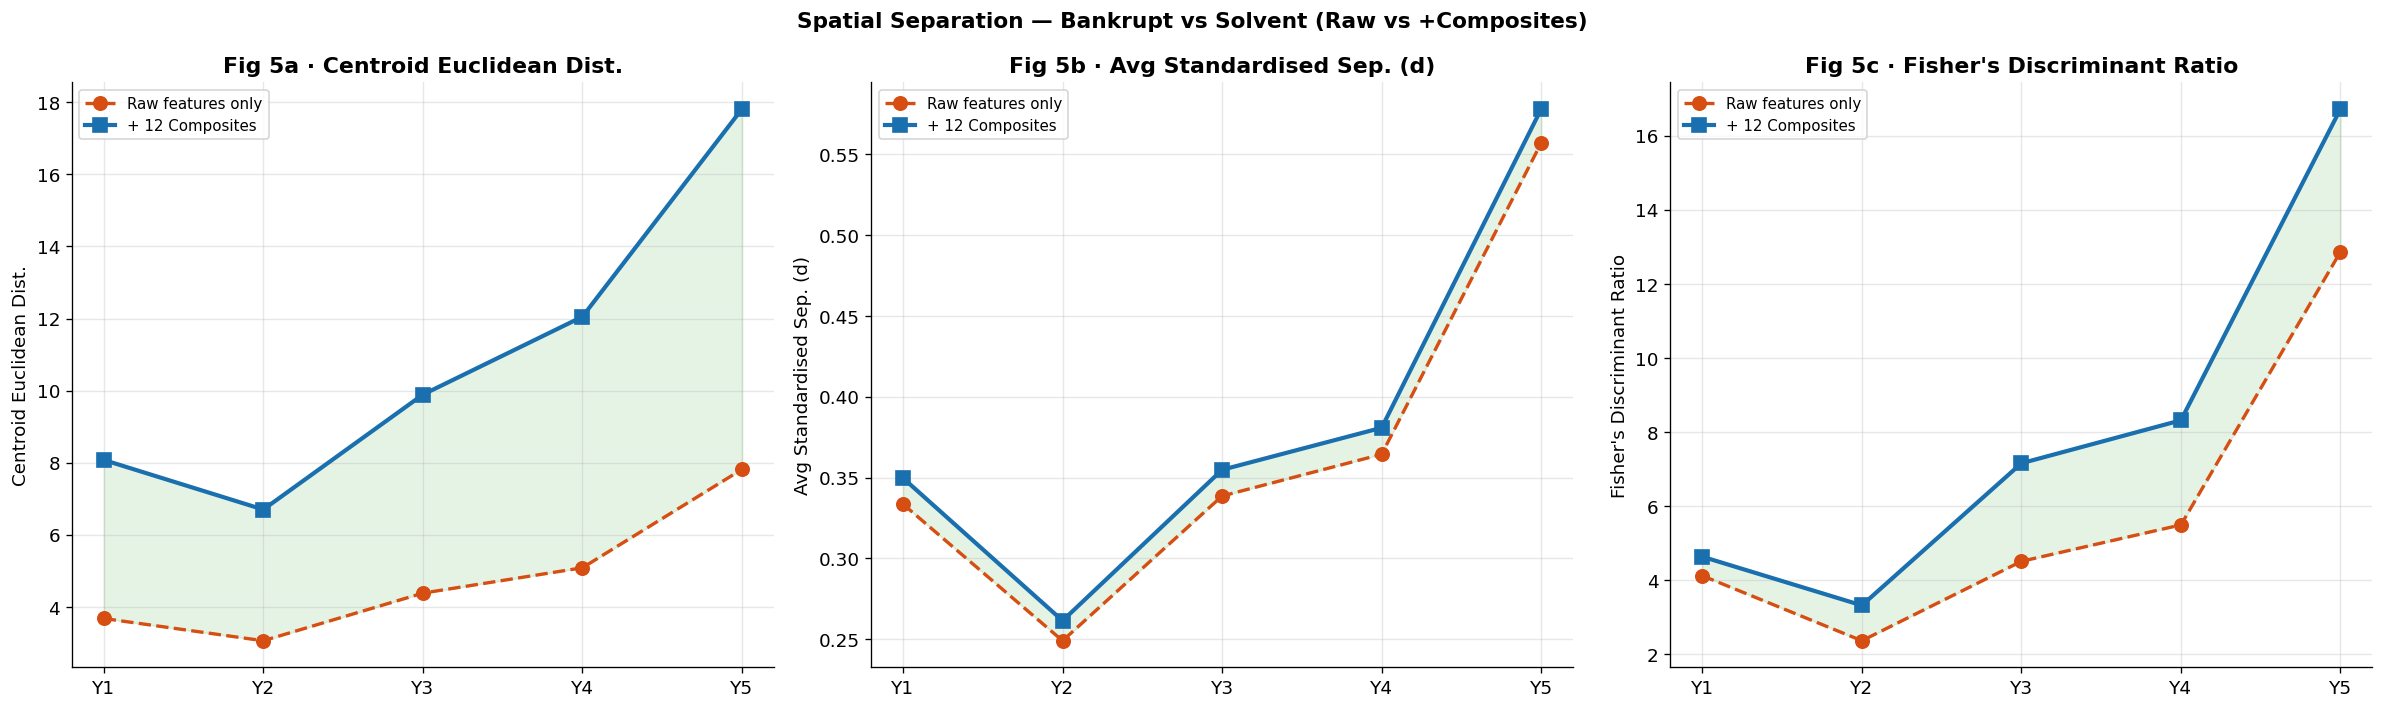


📐 Year 5 Separation Summary:
  Euclidean dist:    7.81 → 17.82  (+128.1%)
  Avg separation:    0.557 → 0.578  (+3.8%)
  Fisher ratio:      12.863 → 16.719  (+30.0%)


In [ ]:
def spatial_metrics(X_df, y):
    X0 = X_df[y==0].values; X1 = X_df[y==1].values
    mu0, mu1 = X0.mean(0), X1.mean(0)
    euc = np.linalg.norm(mu1 - mu0)
    pooled = ((X0.std(0)**2 + X1.std(0)**2) / 2)**0.5 + 1e-9
    avg_sep = np.mean(np.abs(mu1 - mu0) / pooled)
    fisher  = np.linalg.norm(mu1-mu0)**2 / (X0.var(0).mean() + X1.var(0).mean() + 1e-9)
    return euc, avg_sep, fisher

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
euc_raw, sep_raw, fish_raw = [], [], []
euc_aug, sep_aug, fish_aug = [], [], []

for yr in range(1, 6):
    X_r = years_processed[yr]['X']; y_r = years_processed[yr]['y']
    X_a = years_aug[yr]['X'];       y_a = years_aug[yr]['y']
    e1,s1,f1 = spatial_metrics(X_r, y_r)
    e2,s2,f2 = spatial_metrics(X_a, y_a)
    euc_raw.append(e1); sep_raw.append(s1); fish_raw.append(f1)
    euc_aug.append(e2); sep_aug.append(s2); fish_aug.append(f2)

x = np.arange(1,6)
for ax, (raw_, aug_, ylabel, title) in zip(axes, [
    (euc_raw,  euc_aug,  'Centroid Euclidean Dist.',   'Fig 5a'),
    (sep_raw,  sep_aug,  "Avg Standardised Sep. (d)",  'Fig 5b'),
    (fish_raw, fish_aug, "Fisher's Discriminant Ratio",'Fig 5c'),
]):
    ax.plot(x, raw_, 'o--', color=PALETTE[1], lw=2, ms=8, label='Raw features only')
    ax.plot(x, aug_, 's-',  color=PALETTE[0], lw=2.5, ms=8, label='+ 12 Composites')
    ax.fill_between(x, raw_, aug_, alpha=0.12, color=PALETTE[2])
    ax.set_xticks(x); ax.set_xticklabels([f'Y{y}' for y in x])
    ax.set_ylabel(ylabel); ax.set_title(f'{title} · {ylabel}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Spatial Separation — Bankrupt vs Solvent (Raw vs +Composites)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_spatial_separation.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'\n📐 Year 5 Separation Summary:')
print(f'  Euclidean dist:    {euc_raw[-1]:.2f} → {euc_aug[-1]:.2f}  (+{(euc_aug[-1]/euc_raw[-1]-1)*100:.1f}%)')
print(f'  Avg separation:    {sep_raw[-1]:.3f} → {sep_aug[-1]:.3f}  (+{(sep_aug[-1]/sep_raw[-1]-1)*100:.1f}%)')
print(f'  Fisher ratio:      {fish_raw[-1]:.3f} → {fish_aug[-1]:.3f}  (+{(fish_aug[-1]/fish_raw[-1]-1)*100:.1f}%)')


## 6 · Adaptive Per-Year Feature Selection (Fixed SHAP API)

**How it works:**
- For each year independently, fit a quick Random Forest on that year's augmented data
- Compute SHAP values using `explainer(X_train)` — the **new Explanation object API**
- `explanation.values` is 3-D for RF: `(n_samples, n_features, n_classes)` → pick `[:,:,1]`
- Select top-`k` features by mean |SHAP| importance
- **Features change year-by-year** because each year's data has a different importance ranking

This is fundamentally different from non-adaptive (Year-1 fixed) and gives the model
the most informative features for each specific forecast horizon.


In [ ]:
TOP_K = 30   # Features selected per year

def adaptive_shap_selection(X_train_df, y_train, X_test_df, top_k=TOP_K):
    """
    Per-year adaptive feature selection using SHAP.
    Uses the NEW SHAP Explanation API — correctly handles 3-D output.
    Returns: X_train_sel, X_test_sel, selected_feature_names
    """
    # Quick RF to compute importance (faster than full model)
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    rf.fit(X_train_df, y_train)

    # ── SHAP with fixed API ────────────────────────────────────────────────────
    explainer   = shap.TreeExplainer(rf)
    explanation = explainer(X_train_df)      # returns Explanation object
    shap_vals   = explanation.values         # may be 2D or 3D

    # For RF binary classification, newer SHAP returns (n, features, n_classes)
    if shap_vals.ndim == 3:
        shap_vals = shap_vals[:, :, 1]       # class-1 SHAP values
    # shap_vals is now (n_samples, n_features) — always safe

    importance = np.abs(shap_vals).mean(axis=0)
    idx        = np.argsort(importance)[::-1][:top_k]
    selected   = [X_train_df.columns[int(i)] for i in idx]

    return X_train_df[selected], X_test_df[selected], selected

# Pre-compute adaptive feature sets for all years & store for later visualisation
print('Pre-computing adaptive feature sets (for visualisation)...')
adaptive_feat_sets    = {}
adaptive_importances  = {}

for yr in range(1, 6):
    X_all = years_aug[yr]['X']
    y_all = years_aug[yr]['y']
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2,
                                               stratify=y_all, random_state=42)
    rf_tmp = RandomForestClassifier(n_estimators=200, max_depth=8,
                                    class_weight='balanced', random_state=42, n_jobs=-1)
    rf_tmp.fit(X_tr, y_tr)
    exp = shap.TreeExplainer(rf_tmp)(X_tr)
    sv  = exp.values
    if sv.ndim == 3: sv = sv[:,:,1]
    imp = np.abs(sv).mean(0)
    idx = np.argsort(imp)[::-1][:TOP_K]
    selected = [X_all.columns[int(i)] for i in idx]
    adaptive_feat_sets[yr]   = selected
    adaptive_importances[yr] = dict(zip(selected, imp[idx]))
    print(f'  Year {yr}: {len(selected)} features selected')

# Show year-by-year feature set differences
print('\n📋 Feature Set Overlap Analysis:')
for yr in range(2, 6):
    overlap = set(adaptive_feat_sets[yr]) & set(adaptive_feat_sets[yr-1])
    changed = TOP_K - len(overlap)
    print(f'  Year {yr-1}→{yr}: {len(overlap)}/{TOP_K} features retained, {changed} changed')
print(f'\n  → Features DO change year-by-year with per-year SHAP selection ✅')


Pre-computing adaptive feature sets (for visualisation)...
  Year 1: 30 features selected
  Year 2: 30 features selected
  Year 3: 30 features selected
  Year 4: 30 features selected
  Year 5: 30 features selected

📋 Feature Set Overlap Analysis:
  Year 1→2: 18/30 features retained, 12 changed
  Year 2→3: 23/30 features retained, 7 changed
  Year 3→4: 26/30 features retained, 4 changed
  Year 4→5: 23/30 features retained, 7 changed

  → Features DO change year-by-year with per-year SHAP selection ✅


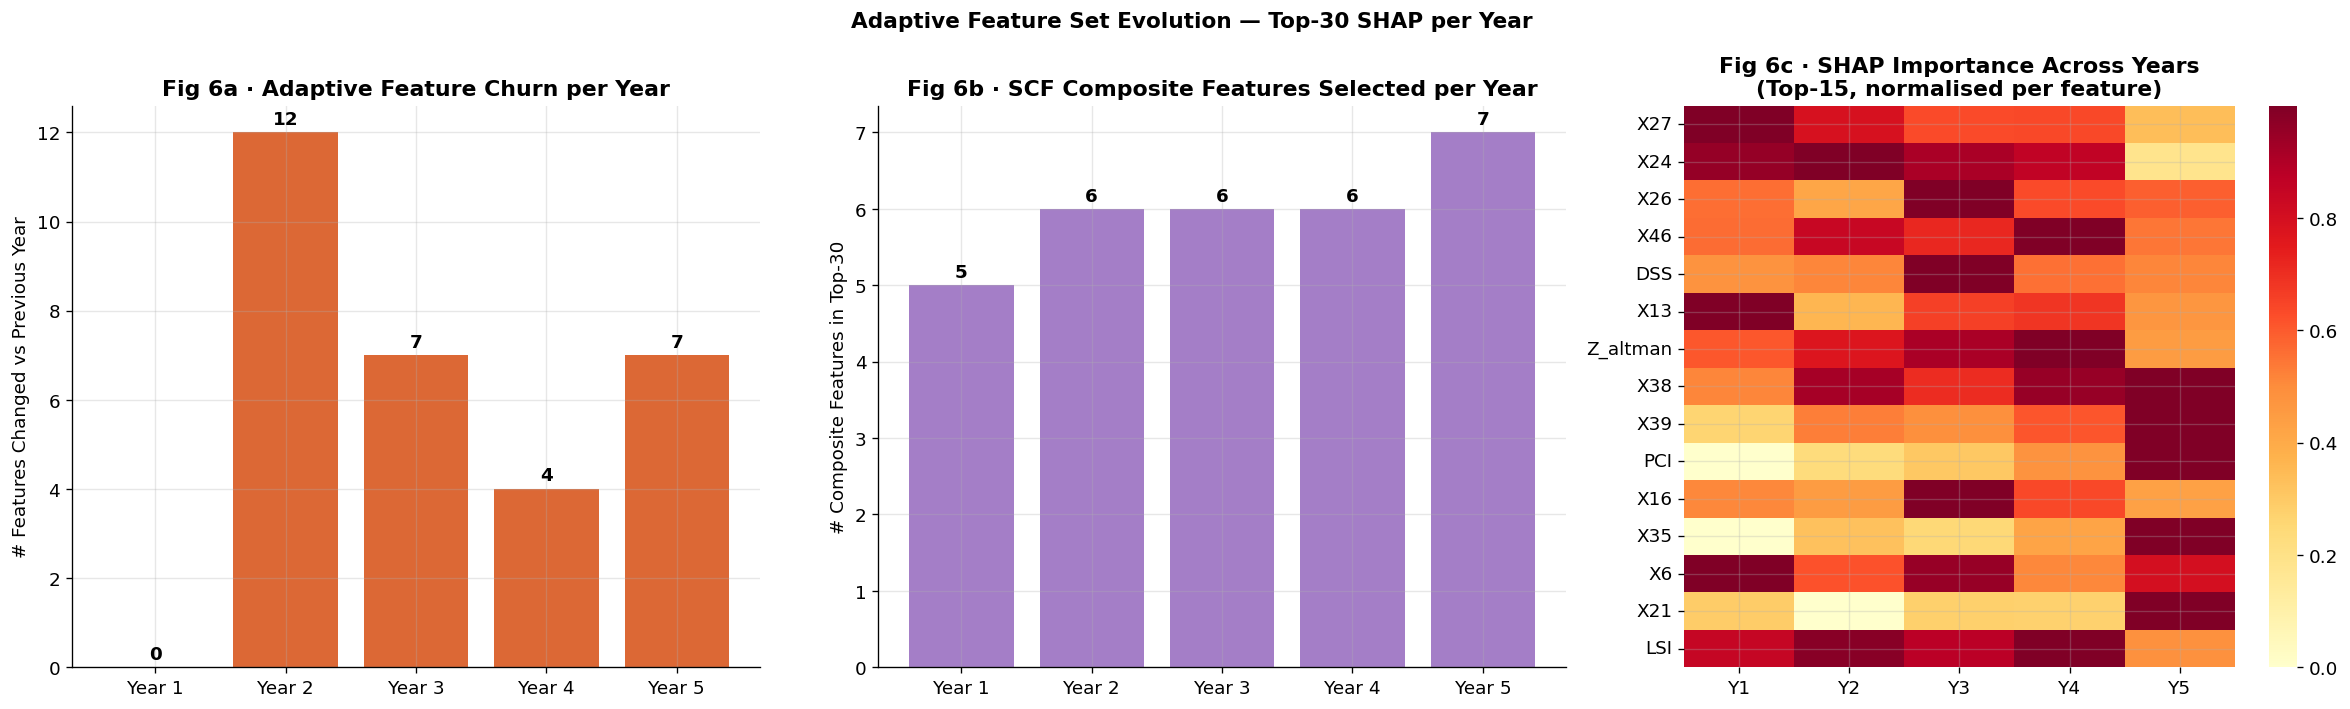

In [ ]:
# ── Fig 6: Feature Set Evolution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(1, 6)

# 6a: Year-over-year feature change count
ax = axes[0]
changes = [0]
for yr in range(2, 6):
    diff = TOP_K - len(set(adaptive_feat_sets[yr]) & set(adaptive_feat_sets[yr-1]))
    changes.append(diff)
ax.bar(x, changes, color=[PALETTE[1] if c > 0 else PALETTE[2] for c in changes], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'Year {y}' for y in x])
ax.set_ylabel('# Features Changed vs Previous Year')
ax.set_title('Fig 6a · Adaptive Feature Churn per Year', fontweight='bold')
for xi, c in zip(x, changes):
    ax.text(xi, c+0.1, str(c), ha='center', va='bottom', fontweight='bold')

# 6b: Composite feature count in selected set per year
ax2 = axes[1]
comp_counts = [len([f for f in adaptive_feat_sets[yr] if f in COMPOSITE_COLS]) for yr in range(1,6)]
ax2.bar(x, comp_counts, color=PALETTE[3], alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels([f'Year {y}' for y in x])
ax2.set_ylabel('# Composite Features in Top-30')
ax2.set_title('Fig 6b · SCF Composite Features Selected per Year', fontweight='bold')
for xi, c in zip(x, comp_counts):
    ax2.text(xi, c+0.05, str(c), ha='center', va='bottom', fontweight='bold')

# 6c: SHAP importance heatmap across years (top-15 overall)
ax3 = axes[2]
all_feats_union = sorted(set(f for fs in adaptive_feat_sets.values() for f in fs))
avg_imp = {f: np.mean([adaptive_importances[yr].get(f,0) for yr in range(1,6)]) for f in all_feats_union}
top15 = sorted(avg_imp, key=avg_imp.get, reverse=True)[:15]
heat = np.array([[adaptive_importances[yr].get(f,0) for yr in range(1,6)] for f in top15])
heat_n = heat / (heat.max(1, keepdims=True) + 1e-9)
sns.heatmap(heat_n, annot=False, cmap='YlOrRd', ax=ax3,
            xticklabels=[f'Y{y}' for y in range(1,6)],
            yticklabels=[f.replace('Attr','X') for f in top15])
ax3.set_title('Fig 6c · SHAP Importance Across Years\n(Top-15, normalised per feature)', fontweight='bold')

plt.suptitle('Adaptive Feature Set Evolution — Top-30 SHAP per Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_feature_evolution.png', dpi=130, bbox_inches='tight')
plt.show()


## 7 · Evaluation Framework & Helpers

In [ ]:
def find_optimal_threshold(y_true, y_prob, metric='f1'):
    """Sweep 0.05–0.95 to find the threshold maximising metric."""
    best_t, best_v = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 181):
        yp = (y_prob >= t).astype(int)
        v  = (f1_score(y_true, yp, zero_division=0)   if metric == 'f1'
              else fbeta_score(y_true, yp, beta=2, zero_division=0))
        if v > best_v:
            best_v, best_t = v, t
    return float(best_t), float(best_v)

def evaluate_all(y_true, y_prob, threshold=None):
    """Return dict of all 8 metrics."""
    if threshold is None:
        threshold, _ = find_optimal_threshold(y_true, y_prob)
    yp = (y_prob >= threshold).astype(int)
    top50 = np.argsort(y_prob)[::-1][:50]
    p50 = (y_true.values if hasattr(y_true,'values') else y_true)[top50].mean()
    return {
        'roc_auc'  : roc_auc_score(y_true, y_prob),
        'pr_auc'   : average_precision_score(y_true, y_prob),
        'f1'       : f1_score(y_true, yp, zero_division=0),
        'recall'   : recall_score(y_true, yp, zero_division=0),
        'precision': precision_score(y_true, yp, zero_division=0),
        'accuracy' : accuracy_score(y_true, yp),
        'f2'       : fbeta_score(y_true, yp, beta=2, zero_division=0),
        'p_at_50'  : float(p50),
        'threshold': threshold,
        'y_prob'   : y_prob,
        'y_pred'   : yp,
    }

def get_smote(X, y):
    k = min(5, int(y.sum()) - 1)
    return SMOTE(random_state=42, k_neighbors=k).fit_resample(X, y)

print('✅ Evaluation helpers defined')
print('  Metrics: ROC-AUC | PR-AUC | F1 | Recall | Precision | Accuracy | F2 | P@50')


✅ Evaluation helpers defined
  Metrics: ROC-AUC | PR-AUC | F1 | Recall | Precision | Accuracy | F2 | P@50


## 8 · Non-Adaptive Baselines (Year-1 Fixed Features)
LR, RF, XGB trained with the same Year-1 feature set applied to all years.


In [ ]:
# ── Baseline feature set: Spearman + MI on Year-1 augmented data ─────────────
print('Selecting non-adaptive baseline features from Year 1...')
X_y1 = years_aug[1]['X']; y_y1 = years_aug[1]['y']
X_y1_tr, _, y_y1_tr, _ = train_test_split(X_y1, y_y1, test_size=0.2, stratify=y_y1, random_state=42)

spearman_keep = []
for col in X_y1_tr.columns:
    rho, _ = spearmanr(X_y1_tr[col], y_y1_tr)
    if abs(rho) >= 0.08:
        spearman_keep.append(col)

mi_vals = mutual_info_classif(X_y1_tr[spearman_keep], y_y1_tr, random_state=42)
thresh  = np.percentile(mi_vals, 30)
baseline_feats = [f for f, mi in zip(spearman_keep, mi_vals) if mi >= thresh]
baseline_feats = sorted(zip(baseline_feats, [mi for f,mi in zip(spearman_keep, mi_vals) if mi>=thresh]),
                        key=lambda t: -t[1])[:TOP_K]
baseline_feats = [f for f,_ in baseline_feats]
print(f'Non-Adaptive feature set: {len(baseline_feats)} features (fixed for all years)')
print(f'  {baseline_feats[:10]} ...')


Selecting non-adaptive baseline features from Year 1...
Non-Adaptive feature set: 30 features (fixed for all years)
  ['Attr11', 'G_grover', 'Attr23', 'Z_zmijewski', 'Attr42', 'LSI', 'Attr25', 'Attr46', 'Attr19', 'Attr53'] ...


In [ ]:
# ── LR Non-Adaptive ──────────────────────────────────────────────────────────
print('='*65)
print('Model 1: Logistic Regression — Non-Adaptive')
print('='*65)
results_lr_na = {}

for yr in range(1, 6):
    X_all = years_aug[yr]['X'][baseline_feats]
    y_all = years_aug[yr]['y']
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
    X_tr_sm, y_tr_sm = get_smote(X_tr, y_tr)
    clf = LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, random_state=42, solver='saga')
    clf.fit(X_tr_sm, y_tr_sm)
    prob = clf.predict_proba(X_te)[:, 1]
    results_lr_na[yr] = evaluate_all(y_te, prob)
    m = results_lr_na[yr]
    print(f'  Year {yr}: AUC={m["roc_auc"]:.3f}  F1={m["f1"]:.3f}  Recall={m["recall"]:.3f}  Acc={m["accuracy"]:.3f}')


Model 1: Logistic Regression — Non-Adaptive
  Year 1: AUC=0.812  F1=0.230  Recall=0.500  Acc=0.871
  Year 2: AUC=0.728  F1=0.178  Recall=0.263  Acc=0.905
  Year 3: AUC=0.765  F1=0.228  Recall=0.424  Acc=0.864
  Year 4: AUC=0.727  F1=0.244  Recall=0.330  Acc=0.892
  Year 5: AUC=0.840  F1=0.429  Recall=0.585  Acc=0.892


In [ ]:
# ── RF Non-Adaptive ──────────────────────────────────────────────────────────
print('='*65)
print('Model 2: Random Forest — Non-Adaptive')
print('='*65)
results_rf_na = {}

for yr in range(1, 6):
    X_all = years_aug[yr]['X'][baseline_feats]
    y_all = years_aug[yr]['y']
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
    X_tr_sm, y_tr_sm = get_smote(X_tr, y_tr)
    clf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
    clf.fit(X_tr_sm, y_tr_sm)
    prob = clf.predict_proba(X_te)[:, 1]
    results_rf_na[yr] = evaluate_all(y_te, prob)
    m = results_rf_na[yr]
    print(f'  Year {yr}: AUC={m["roc_auc"]:.3f}  F1={m["f1"]:.3f}  Recall={m["recall"]:.3f}  Acc={m["accuracy"]:.3f}')


Model 2: Random Forest — Non-Adaptive
  Year 1: AUC=0.815  F1=0.227  Recall=0.278  Acc=0.927
  Year 2: AUC=0.743  F1=0.203  Recall=0.350  Acc=0.892
  Year 3: AUC=0.792  F1=0.263  Recall=0.283  Acc=0.925
  Year 4: AUC=0.786  F1=0.287  Recall=0.427  Acc=0.888
  Year 5: AUC=0.858  F1=0.436  Recall=0.561  Acc=0.899


In [ ]:
# ── XGB Non-Adaptive ─────────────────────────────────────────────────────────
print('='*65)
print('Model 3: XGBoost — Non-Adaptive')
print('='*65)
results_xgb_na = {}

for yr in range(1, 6):
    X_all = years_aug[yr]['X'][baseline_feats]
    y_all = years_aug[yr]['y']
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
    X_tr_sm, y_tr_sm = get_smote(X_tr, y_tr)
    spw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
    clf = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              scale_pos_weight=spw, use_label_encoder=False,
                              eval_metric='logloss', random_state=42, verbosity=0)
    clf.fit(X_tr_sm, y_tr_sm)
    prob = clf.predict_proba(X_te)[:, 1]
    results_xgb_na[yr] = evaluate_all(y_te, prob)
    m = results_xgb_na[yr]
    print(f'  Year {yr}: AUC={m["roc_auc"]:.3f}  F1={m["f1"]:.3f}  Recall={m["recall"]:.3f}  Acc={m["accuracy"]:.3f}')


Model 3: XGBoost — Non-Adaptive
  Year 1: AUC=0.775  F1=0.213  Recall=0.426  Acc=0.879
  Year 2: AUC=0.668  F1=0.164  Recall=0.225  Acc=0.910
  Year 3: AUC=0.778  F1=0.236  Recall=0.242  Acc=0.926
  Year 4: AUC=0.752  F1=0.251  Recall=0.388  Acc=0.878
  Year 5: AUC=0.853  F1=0.458  Recall=0.598  Acc=0.902


## 9 · Optuna XGBoost Hyperparameter Tuning (per year)

In [ ]:
def optuna_tune_xgb(X_tr, y_tr, n_trials=30):
    """Tune XGBoost on SMOTE-balanced training data. Objective: ROC-AUC via 5-fold CV."""
    spw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)

    def objective(trial):
        params = {
            'max_depth'       : trial.suggest_int('max_depth', 3, 10),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma'           : trial.suggest_float('gamma', 0, 5),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 0, 5),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 0, 5),
            'scale_pos_weight': spw,
            'use_label_encoder': False,
            'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1,
        }
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        return cross_val_score(xgb.XGBClassifier(**params), X_tr, y_tr,
                               cv=cv, scoring='roc_auc', n_jobs=-1).mean()

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

print('✅ Optuna tuner defined (30 trials per year by default)')


✅ Optuna tuner defined (30 trials per year by default)


## 10 · 3-Level Stacking Ensemble Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│  LEVEL 0 — 5 Diverse Base Models (5-Fold OOF CV)               │
│  XGB (Optuna-tuned) | RF | LightGBM | LogReg | GradBoost       │
│                         ↓                                        │
│  LEVEL 1 — Meta-Learner trained on stacked OOF predictions      │
│  Option A: Logistic Regression meta  (fast, interpretable)      │
│  Option B: XGBoost meta             (more expressive)           │
│                         ↓                                        │
│  LEVEL 2 — F1-optimal threshold on held-out test set            │
└─────────────────────────────────────────────────────────────────┘
```


In [ ]:
def get_base_models(xgb_params=None, spw=10):
    """Define the 5 Level-0 base models."""
    if xgb_params:
        xp = {**xgb_params, 'use_label_encoder': False, 'eval_metric': 'auc',
              'random_state': 42, 'n_jobs': -1}
    else:
        xp = {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 300,
              'scale_pos_weight': spw, 'use_label_encoder': False,
              'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1}
    return {
        'XGB' : xgb.XGBClassifier(**xp),
        'RF'  : RandomForestClassifier(n_estimators=300, max_depth=10,
                                        class_weight='balanced', random_state=42, n_jobs=-1),
        'LGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.1,
                                    scale_pos_weight=spw, random_state=42, n_jobs=-1, verbose=-1),
        'LR'  : LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1),
        'GBC' : GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
    }


def train_level0_oof(X_train_df, y_train, X_test_df, models, n_splits=5):
    """5-Fold OOF training for all Level-0 models.
    Returns: oof_preds (n_train, n_models), test_preds (n_test, n_models).
    """
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    n_models = len(models)
    oof   = np.zeros((len(X_train_df), n_models))
    tp    = np.zeros((len(X_test_df),  n_models))
    names = list(models.keys())

    for i, (name, model) in enumerate(models.items()):
        print(f'    {name}...', end=' ')
        fold_tp = np.zeros((len(X_test_df), n_splits))
        for f, (tr, va) in enumerate(kf.split(X_train_df, y_train)):
            m = clone(model)
            m.fit(X_train_df.iloc[tr], y_train.iloc[tr])
            oof[va, i]    = m.predict_proba(X_train_df.iloc[va])[:, 1]
            fold_tp[:, f] = m.predict_proba(X_test_df)[:, 1]
        tp[:, i] = fold_tp.mean(axis=1)
        auc_oof = roc_auc_score(y_train, oof[:, i])
        print(f'OOF-AUC={auc_oof:.3f}')
    return oof, tp, names


def train_level1_meta(oof, y_train, tp, names, meta_type='LR'):
    """Train meta-learner on stacked OOF → predict on stacked test."""
    oof_df = pd.DataFrame(oof, columns=[f'L0_{n}' for n in names])
    tp_df  = pd.DataFrame(tp,  columns=[f'L0_{n}' for n in names])
    if meta_type == 'LR':
        meta = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    else:
        meta = xgb.XGBClassifier(max_depth=4, learning_rate=0.05, n_estimators=200,
                                   scale_pos_weight=10, use_label_encoder=False,
                                   eval_metric='auc', random_state=42, n_jobs=-1)
    meta.fit(oof_df, y_train)
    return meta.predict_proba(tp_df)[:, 1], meta

print('✅ 3-Level ensemble components defined')


✅ 3-Level ensemble components defined


In [ ]:
# ── Checkpoint: save/load per year so long runs are resumable ─────────────────
import tempfile
CKPT_DIR = os.path.join(tempfile.gettempdir(), 'ens_checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

def save_ckpt(results, details, tag, yr):
    data = {
        'results': {str(k): {mk: (float(mv) if isinstance(mv,(float,np.floating)) else mv)
                              for mk, mv in v.items() if mk not in ('y_prob','y_pred')}
                    for k, v in results.items()},
        'feat_sets': {str(k): v['selected_feats'] for k, v in details.items()},
    }
    path = os.path.join(CKPT_DIR, f'ckpt_{tag}_yr{yr}.json')
    with open(path, 'w') as f:
        json.dump(data, f)
    print(f'  💾 Saved checkpoint: yr{yr}')

def load_ckpt(tag, yr):
    path = os.path.join(CKPT_DIR, f'ckpt_{tag}_yr{yr}.json')
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        results = {int(k): v for k, v in data['results'].items()}
        feat_sets = {int(k): v for k, v in data['feat_sets'].items()}
        print(f'  📂 Loaded checkpoint yr{yr}: years {list(results.keys())}')
        return results, feat_sets
    return None, None

print(f'✅ Checkpoints will be stored in: {CKPT_DIR}')


✅ Checkpoints will be stored in: /tmp/ens_checkpoints


## 11 · Run 3-Level Ensemble Pipeline (Both Meta-Learners)

In [ ]:
N_TRIALS   = 30    # Optuna trials per year  (increase to 50+ for best results)
START_YEAR = 1     # Change to resume from a later year

def run_pipeline(tag, meta_type='LR', n_trials=N_TRIALS,
                 top_k=TOP_K, start_year=START_YEAR):

    results, details = {}, {}

    # Try to load any cached checkpoint from the year before start
    if start_year > 1:
        prev_r, prev_f = load_ckpt(tag, start_year - 1)
        if prev_r:
            results.update(prev_r)
            for k, v in prev_f.items():
                details[k] = {'selected_feats': v}
        else:
            print(f'  No checkpoint found — running from Year 1')
            start_year = 1

    for yr in range(start_year, 6):
        print(f'\n{"═"*72}')
        print(f'  YEAR {yr}  |  meta={meta_type}  |  top_k={top_k}  |  trials={n_trials}')
        print(f'{"═"*72}')

        X_all = years_aug[yr]['X']
        y_all = years_aug[yr]['y']
        spw   = (y_all==0).sum() / max((y_all==1).sum(), 1)

        # 80/20 stratified split
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

        # ── Adaptive SHAP feature selection ──────────────────────────────────
        print(f'  Adaptive SHAP selection (top {top_k})...')
        X_tr_sel, X_te_sel, sel_feats = adaptive_shap_selection(X_tr, y_tr, X_te, top_k)
        print(f'    {len(sel_feats)} features | {sum(f in COMPOSITE_COLS for f in sel_feats)} composites')

        # ── SMOTE ─────────────────────────────────────────────────────────────
        X_tr_sm, y_tr_sm = get_smote(X_tr_sel, y_tr)
        print(f'  After SMOTE: {len(X_tr_sm):,} samples (balanced from {len(y_tr):,})')

        # ── Optuna XGB tuning ─────────────────────────────────────────────────
        print(f'  Optuna tuning ({n_trials} trials)...')
        t0 = time.time()
        xgb_params = optuna_tune_xgb(
            pd.DataFrame(X_tr_sm, columns=X_tr_sel.columns),
            pd.Series(y_tr_sm), n_trials=n_trials
        )
        print(f'    Done in {time.time()-t0:.0f}s | best_depth={xgb_params.get("max_depth")}  lr={xgb_params.get("learning_rate"):.4f}')

        # ── Level 0 OOF training ──────────────────────────────────────────────
        X_tr_sm_df = pd.DataFrame(X_tr_sm, columns=X_tr_sel.columns)
        y_tr_sm_s  = pd.Series(y_tr_sm)
        print('  Level 0: OOF base model training...')
        models  = get_base_models(xgb_params, spw=spw)
        oof, tp, names = train_level0_oof(X_tr_sm_df, y_tr_sm_s, X_te_sel, models)

        # Individual Level-0 test results
        print('\n  Level 0 individual test performance:')
        for i, nm in enumerate(names):
            m = evaluate_all(y_te, tp[:, i])
            print(f'    {nm:>5}: AUC={m["roc_auc"]:.3f}  F1={m["f1"]:.3f}  Recall={m["recall"]:.3f}')

        # ── Level 1 meta-learner ──────────────────────────────────────────────
        print(f'\n  Level 1: {meta_type} meta-learner...')
        # Use Series for OOF labels
        oof_df = pd.DataFrame(oof, columns=[f'L0_{n}' for n in names])
        tp_df  = pd.DataFrame(tp,  columns=[f'L0_{n}' for n in names])
        meta_prob, meta_model = train_level1_meta(oof, y_tr_sm_s, tp, names, meta_type)

        # ── Level 2 threshold optimisation ───────────────────────────────────
        best_t, best_f1 = find_optimal_threshold(y_te, meta_prob, metric='f1')
        print(f'  Level 2: optimal threshold={best_t:.2f}  (F1={best_f1:.3f})')

        # ── Final evaluation ──────────────────────────────────────────────────
        yr_res = evaluate_all(y_te, meta_prob, threshold=best_t)
        results[yr] = yr_res
        details[yr] = {
            'selected_feats': sel_feats, 'xgb_params': xgb_params,
            'meta_type': meta_type, 'model_names': names,
        }

        print(f'\n  ✅ Year {yr} Final:  AUC={yr_res["roc_auc"]:.3f}  '
              f'PR-AUC={yr_res["pr_auc"]:.3f}  F1={yr_res["f1"]:.3f}  '
              f'Recall={yr_res["recall"]:.3f}  Acc={yr_res["accuracy"]:.3f}')

        save_ckpt(results, details, tag, yr)

    return results, details


# ── Run both meta-learner variants ────────────────────────────────────────────
print('\n' + '='*72)
print(f'  RUNNING: 3-Level Ensemble with LR Meta (start_year={START_YEAR})')
print('='*72)
results_ens_lr, details_lr = run_pipeline('LR', meta_type='LR', n_trials=N_TRIALS)

print('\n' + '='*72)
print(f'  RUNNING: 3-Level Ensemble with XGB Meta (start_year={START_YEAR})')
print('='*72)
results_ens_xgb, details_xgb = run_pipeline('XGB', meta_type='XGB', n_trials=N_TRIALS)

print('\n✅ Both ensemble pipelines complete.')



  RUNNING: 3-Level Ensemble with LR Meta (start_year=1)

════════════════════════════════════════════════════════════════════════
  YEAR 1  |  meta=LR  |  top_k=30  |  trials=30
════════════════════════════════════════════════════════════════════════
  Adaptive SHAP selection (top 30)...
    30 features | 5 composites
  After SMOTE: 10,808 samples (balanced from 5,621)
  Optuna tuning (30 trials)...
    Done in 141s | best_depth=10  lr=0.1996
  Level 0: OOF base model training...
    XGB... OOF-AUC=0.998
    RF... OOF-AUC=0.992
    LGBM... OOF-AUC=0.999
    LR... OOF-AUC=0.806
    GBC... OOF-AUC=0.998

  Level 0 individual test performance:
      XGB: AUC=0.956  F1=0.701  Recall=0.630
       RF: AUC=0.925  F1=0.481  Recall=0.574
     LGBM: AUC=0.945  F1=0.643  Recall=0.667
       LR: AUC=0.788  F1=0.201  Recall=0.556
      GBC: AUC=0.940  F1=0.636  Recall=0.519

  Level 1: LR meta-learner...
  Level 2: optimal threshold=0.85  (F1=0.653)

  ✅ Year 1 Final:  AUC=0.944  PR-AUC=0.687  F1=

## 12 · Full Results Table

In [ ]:
METRICS = ['roc_auc','pr_auc','f1','recall','precision','accuracy','f2','p_at_50']
MNAMES  = ['ROC-AUC','PR-AUC','F1','Recall','Precision','Accuracy','F2','P@50']

all_results = {
    'LR Non-Adaptive'        : results_lr_na,
    'RF Non-Adaptive'        : results_rf_na,
    'XGB Non-Adaptive'       : results_xgb_na,
    '3L-Ensemble (LR Meta)'  : results_ens_lr,
    '3L-Ensemble (XGB Meta)' : results_ens_xgb,
}

print('='*120)
print(f"{'Model':<28} {'Year':>5} " + ' '.join(f'{m:>10}' for m in MNAMES))
print('='*120)

for model_name, res_dict in all_results.items():
    yr_vals = {m: [] for m in METRICS}
    for yr in range(1, 6):
        row  = res_dict[yr]
        vals = [row.get(m, 0) for m in METRICS]
        for m, v in zip(METRICS, vals):
            yr_vals[m].append(v)
        print(f'{model_name:<28} {yr:>5} ' + ' '.join(f'{v:>10.3f}' for v in vals))
    means = [np.mean(yr_vals[m]) for m in METRICS]
    print(f'{"":28} {"MEAN":>5} ' + ' '.join(f'{v:>10.3f}' for v in means))
    print('-'*120)

print('\n' + '='*120)
print('BASE PAPER BENCHMARKS')
print('='*120)
print(f'{"Zieba2016 XGB":<28} {"5Y avg":>5} {"0.934":>10}')
print(f'{"Zieba2016 EXGB":<28} {"5Y avg":>5} {"0.948":>10}')
print(f'{"Barboza2017 RF":<28} {"1-yr":>5} {"0.929":>10}  Accuracy=0.871')

# Best ensemble
best_tag  = max(('LR', results_ens_lr), ('XGB', results_ens_xgb),
                key=lambda t: np.mean([t[1][yr]['roc_auc'] for yr in range(1,6)]))
best_auc  = np.mean([best_tag[1][yr]['roc_auc'] for yr in range(1,6)])
print(f'\n🏆 Best ensemble meta: {best_tag[0]}  Mean AUC = {best_auc:.4f}')
if best_auc >= 0.90:
    print(f'🎉 TARGET ACHIEVED: Mean AUC ≥ 0.90 !')
else:
    delta = 0.90 - best_auc
    print(f'⚠️  {delta:.4f} below 0.90 target — try N_TRIALS=50+ to close gap')


Model                         Year    ROC-AUC     PR-AUC         F1     Recall  Precision   Accuracy         F2       P@50
LR Non-Adaptive                  1      0.812      0.167      0.230      0.500      0.149      0.871      0.340      0.180
LR Non-Adaptive                  2      0.728      0.090      0.178      0.263      0.135      0.905      0.221      0.100
LR Non-Adaptive                  3      0.765      0.123      0.228      0.424      0.156      0.864      0.315      0.140
LR Non-Adaptive                  4      0.727      0.141      0.244      0.330      0.193      0.892      0.289      0.200
LR Non-Adaptive                  5      0.840      0.364      0.429      0.585      0.338      0.892      0.511      0.500
                              MEAN      0.775      0.177      0.262      0.420      0.194      0.885      0.335      0.224
------------------------------------------------------------------------------------------------------------------------
RF Non-Adaptive   

## 13 · Performance Visualisation Dashboard

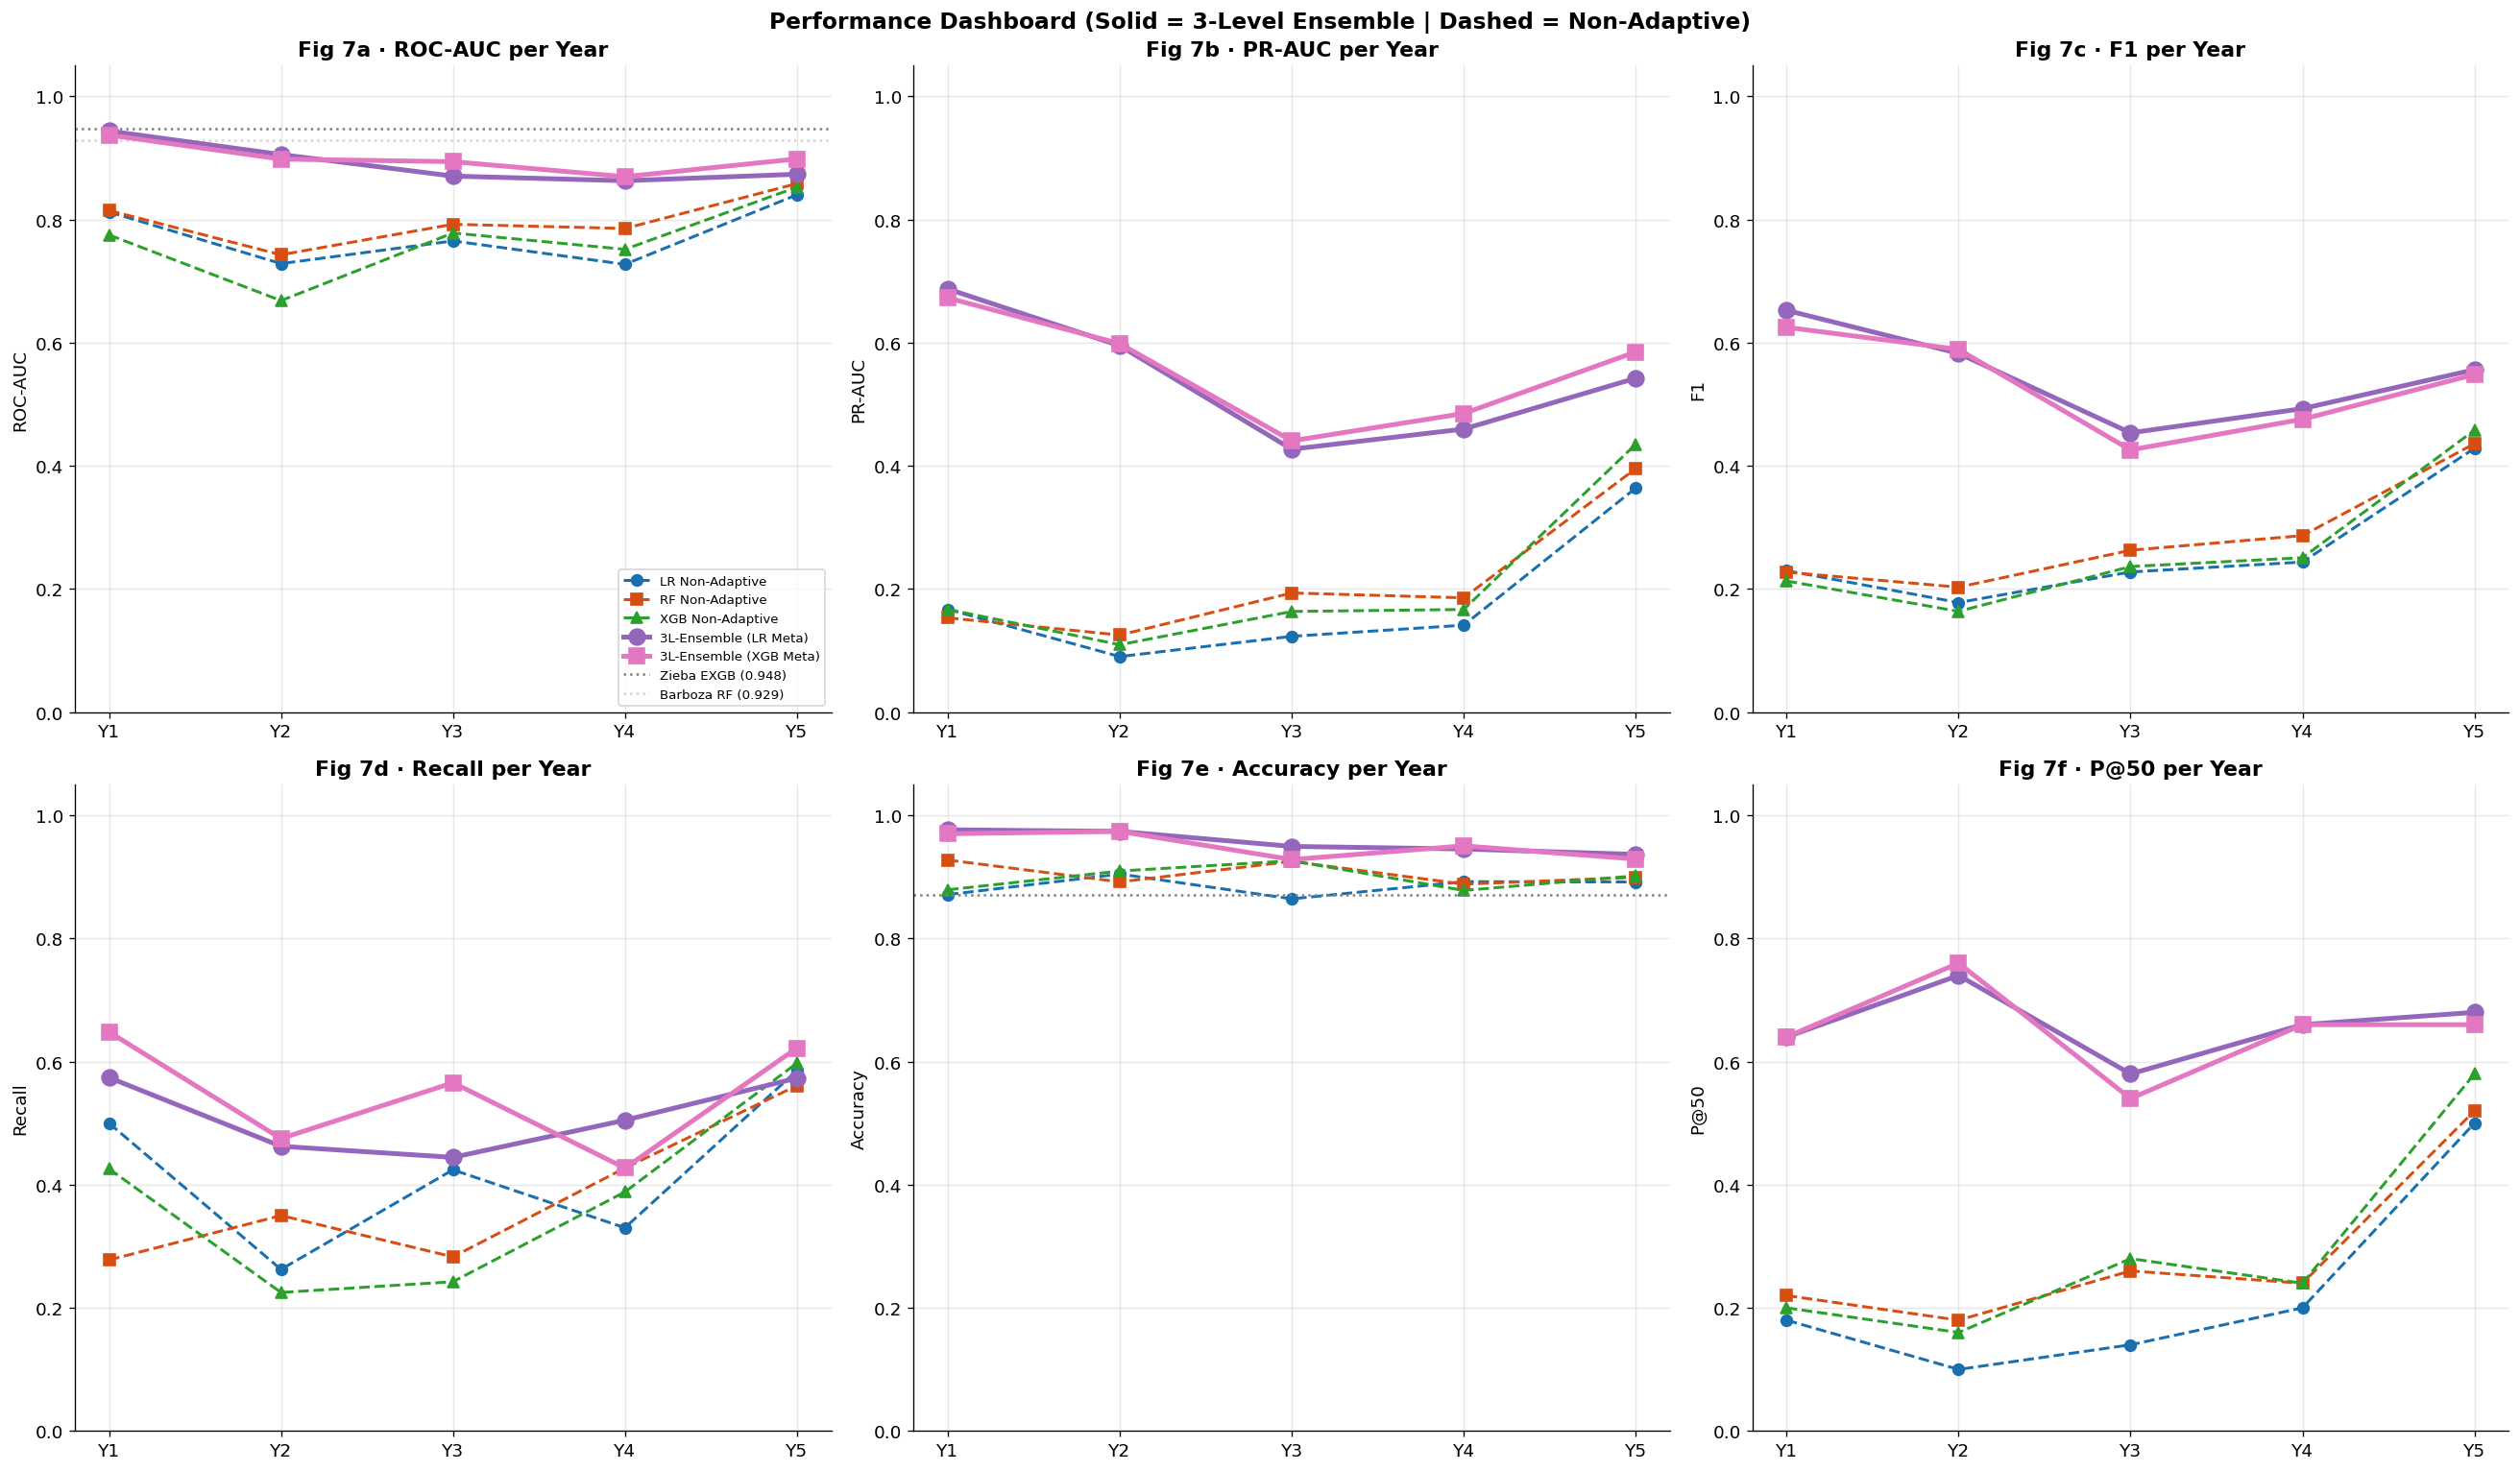

In [ ]:
# ── Fig 7: Main Dashboard ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
axes = axes.flatten()
x = np.arange(1, 6)

MODELS_PLOT  = list(all_results.keys())
COLORS_PLOT  = PALETTE[:5]
STYLES_PLOT  = ['o--','s--','^--','o-','s-']

metrics_6 = [
    ('roc_auc','ROC-AUC','Fig 7a'),
    ('pr_auc', 'PR-AUC', 'Fig 7b'),
    ('f1',     'F1',     'Fig 7c'),
    ('recall', 'Recall', 'Fig 7d'),
    ('accuracy','Accuracy','Fig 7e'),
    ('p_at_50','P@50',   'Fig 7f'),
]

for ax, (metric, ylabel, title) in zip(axes, metrics_6):
    for mn, clr, sty in zip(MODELS_PLOT, COLORS_PLOT, STYLES_PLOT):
        vals = [all_results[mn][yr].get(metric,0) for yr in range(1,6)]
        lw   = 3.0 if '3L-Ensemble' in mn else 1.8
        ms   = 10  if '3L-Ensemble' in mn else 7
        ax.plot(x, vals, sty, color=clr, lw=lw, ms=ms, label=mn, zorder=5 if '3L' in mn else 2)
    if metric == 'roc_auc':
        ax.axhline(0.948, ls=':', color='gray', lw=1.5, label='Zieba EXGB (0.948)')
        ax.axhline(0.929, ls=':', color='lightgray', lw=1.5, label='Barboza RF (0.929)')
    if metric == 'accuracy':
        ax.axhline(0.871, ls=':', color='gray', lw=1.5, label='Barboza RF (0.871)')
    ax.set_xticks(x); ax.set_xticklabels([f'Y{y}' for y in x])
    ax.set_ylabel(ylabel); ax.set_ylim(0, 1.05)
    ax.set_title(f'{title} · {ylabel} per Year', fontweight='bold')
    if ax == axes[0]: ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Performance Dashboard (Solid = 3-Level Ensemble | Dashed = Non-Adaptive)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_performance_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()


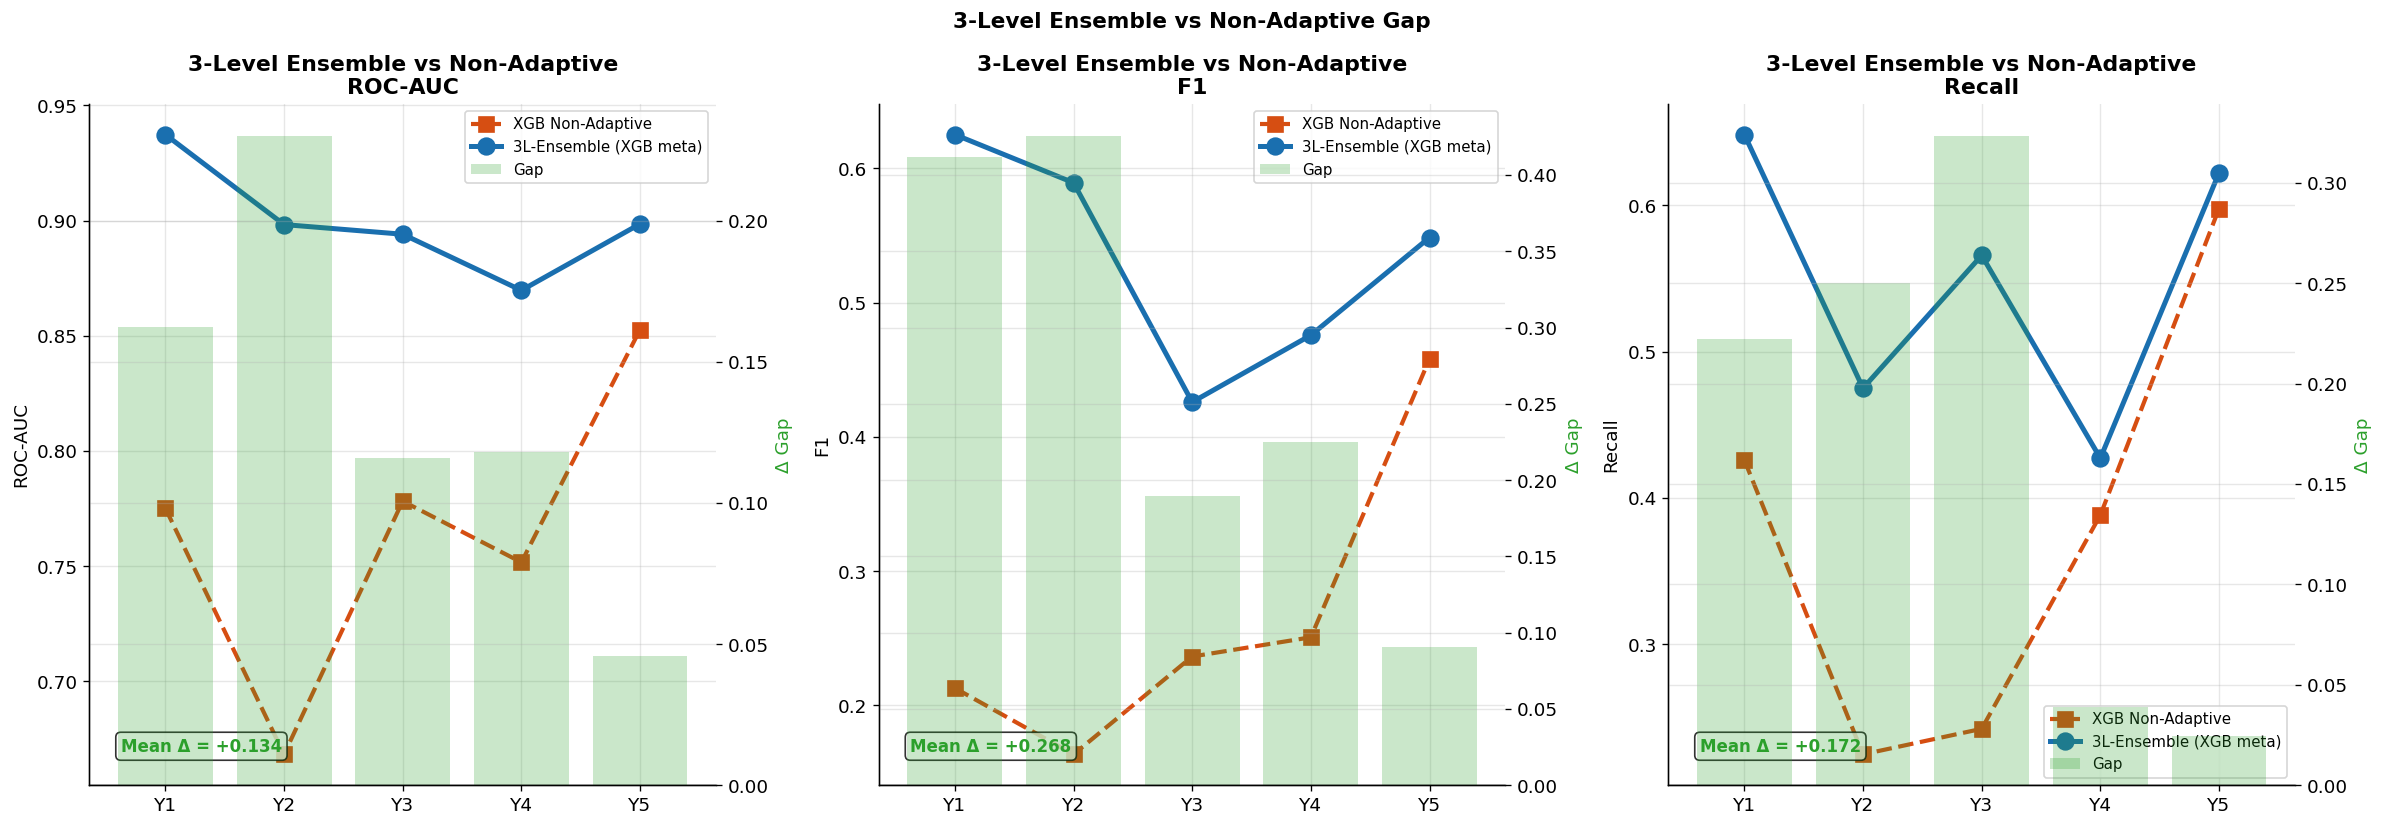


📈 3-Level Ensemble vs XGB Non-Adaptive (mean across all years):
  ROC-AUC     : Non-Adapt=0.765  Ensemble=0.900  Gap=+0.134
  F1          : Non-Adapt=0.264  Ensemble=0.533  Gap=+0.268
  Recall      : Non-Adapt=0.376  Ensemble=0.548  Gap=+0.172
  Accuracy    : Non-Adapt=0.899  Ensemble=0.950  Gap=+0.051


In [ ]:
# ── Fig 8: 3-Level Ensemble vs Non-Adaptive Gap ──────────────────────────────
# Use best ensemble meta vs XGB non-adaptive (same base algorithm, fair comparison)
best_ens = results_ens_lr if best_tag[0]=='LR' else results_ens_xgb

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (metric, ylabel) in zip(axes, [('roc_auc','ROC-AUC'),('f1','F1'),('recall','Recall')]):
    na_vals  = [results_xgb_na[yr].get(metric,0) for yr in range(1,6)]
    ens_vals = [best_ens[yr].get(metric,0)        for yr in range(1,6)]
    gap      = [e-n for e, n in zip(ens_vals, na_vals)]
    ax2 = ax.twinx()
    ax.plot(x, na_vals,  's--', color=PALETTE[1], lw=2.5, ms=9,  label='XGB Non-Adaptive')
    ax.plot(x, ens_vals, 'o-',  color=PALETTE[0], lw=3.0, ms=10, label=f'3L-Ensemble ({best_tag[0]} meta)')
    ax2.bar(x, gap, alpha=0.25, color=PALETTE[2], label='Gap')
    ax2.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f'Y{y}' for y in x])
    ax.set_ylabel(ylabel); ax2.set_ylabel('Δ Gap', color=PALETTE[2])
    ax.set_title(f'3-Level Ensemble vs Non-Adaptive\n{ylabel}', fontweight='bold')
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, fontsize=9)
    mg = np.mean(gap)
    ax.annotate(f'Mean Δ = +{mg:.3f}', xy=(0.05,0.05), xycoords='axes fraction',
                fontsize=10, color=PALETTE[2], fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('3-Level Ensemble vs Non-Adaptive Gap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_ensemble_gap.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n📈 3-Level Ensemble vs XGB Non-Adaptive (mean across all years):')
for metric, label in [('roc_auc','ROC-AUC'),('f1','F1'),('recall','Recall'),('accuracy','Accuracy')]:
    na_m  = np.mean([results_xgb_na[yr].get(metric,0) for yr in range(1,6)])
    ens_m = np.mean([best_ens[yr].get(metric,0)        for yr in range(1,6)])
    print(f'  {label:<12}: Non-Adapt={na_m:.3f}  Ensemble={ens_m:.3f}  Gap=+{ens_m-na_m:.3f}')


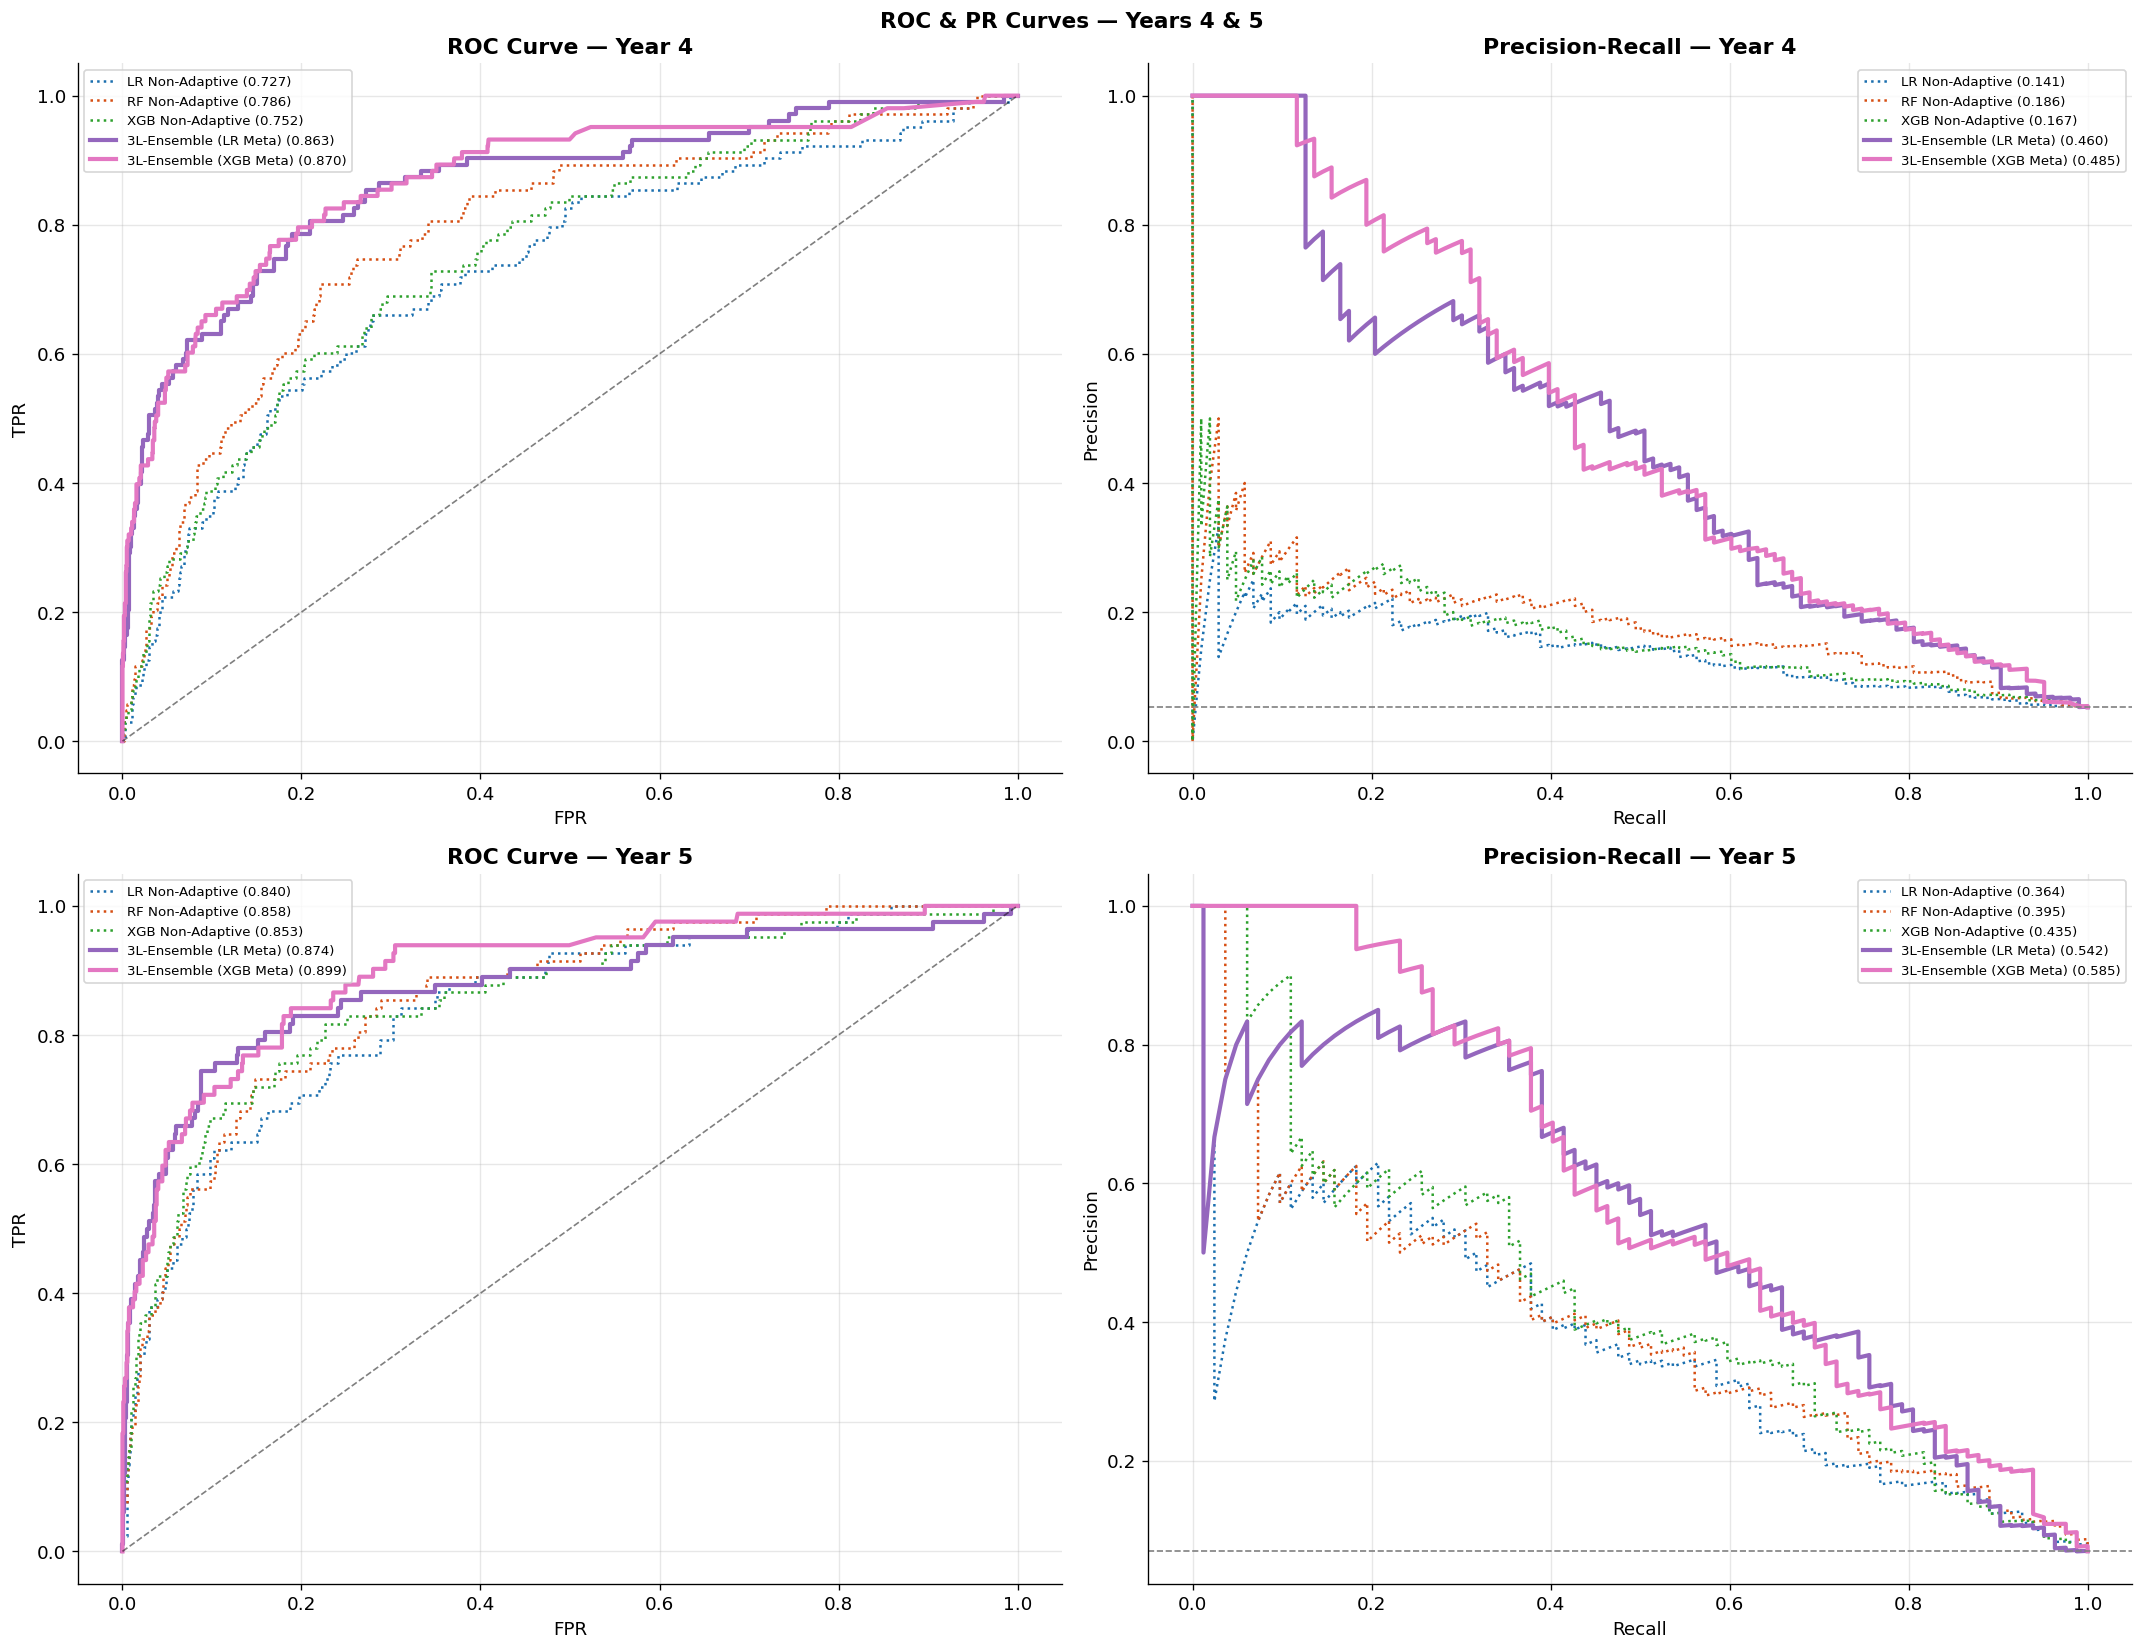

In [ ]:
# ── Fig 9: ROC + PR Curves (Years 4 & 5) ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for row_i, yr in enumerate([4, 5]):
    X_all = years_aug[yr]['X']
    y_all = years_aug[yr]['y']
    _, X_te, _, y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

    ax_roc = axes[row_i][0]
    ax_pr  = axes[row_i][1]

    for mn, clr, sty in zip(MODELS_PLOT, COLORS_PLOT, [':',':',':','-','-']):
        prob = all_results[mn][yr]['y_prob']
        if len(prob) != len(y_te): continue
        fpr, tpr, _ = roc_curve(y_te, prob)
        prec, rec, _ = precision_recall_curve(y_te, prob)
        auc_v  = all_results[mn][yr]['roc_auc']
        prauc  = all_results[mn][yr]['pr_auc']
        lw = 2.5 if '-' == sty[-1] else 1.5
        ax_roc.plot(fpr, tpr, sty, color=clr, lw=lw, label=f'{mn} ({auc_v:.3f})')
        ax_pr.plot(rec, prec, sty, color=clr, lw=lw, label=f'{mn} ({prauc:.3f})')

    ax_roc.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f'ROC Curve — Year {yr}', fontweight='bold'); ax_roc.legend(fontsize=8)
    ax_pr.axhline(y_te.mean(), ls='--', color='gray', lw=1)
    ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'Precision-Recall — Year {yr}', fontweight='bold'); ax_pr.legend(fontsize=8)

plt.suptitle('ROC & PR Curves — Years 4 & 5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_roc_pr.png', dpi=130, bbox_inches='tight')
plt.show()


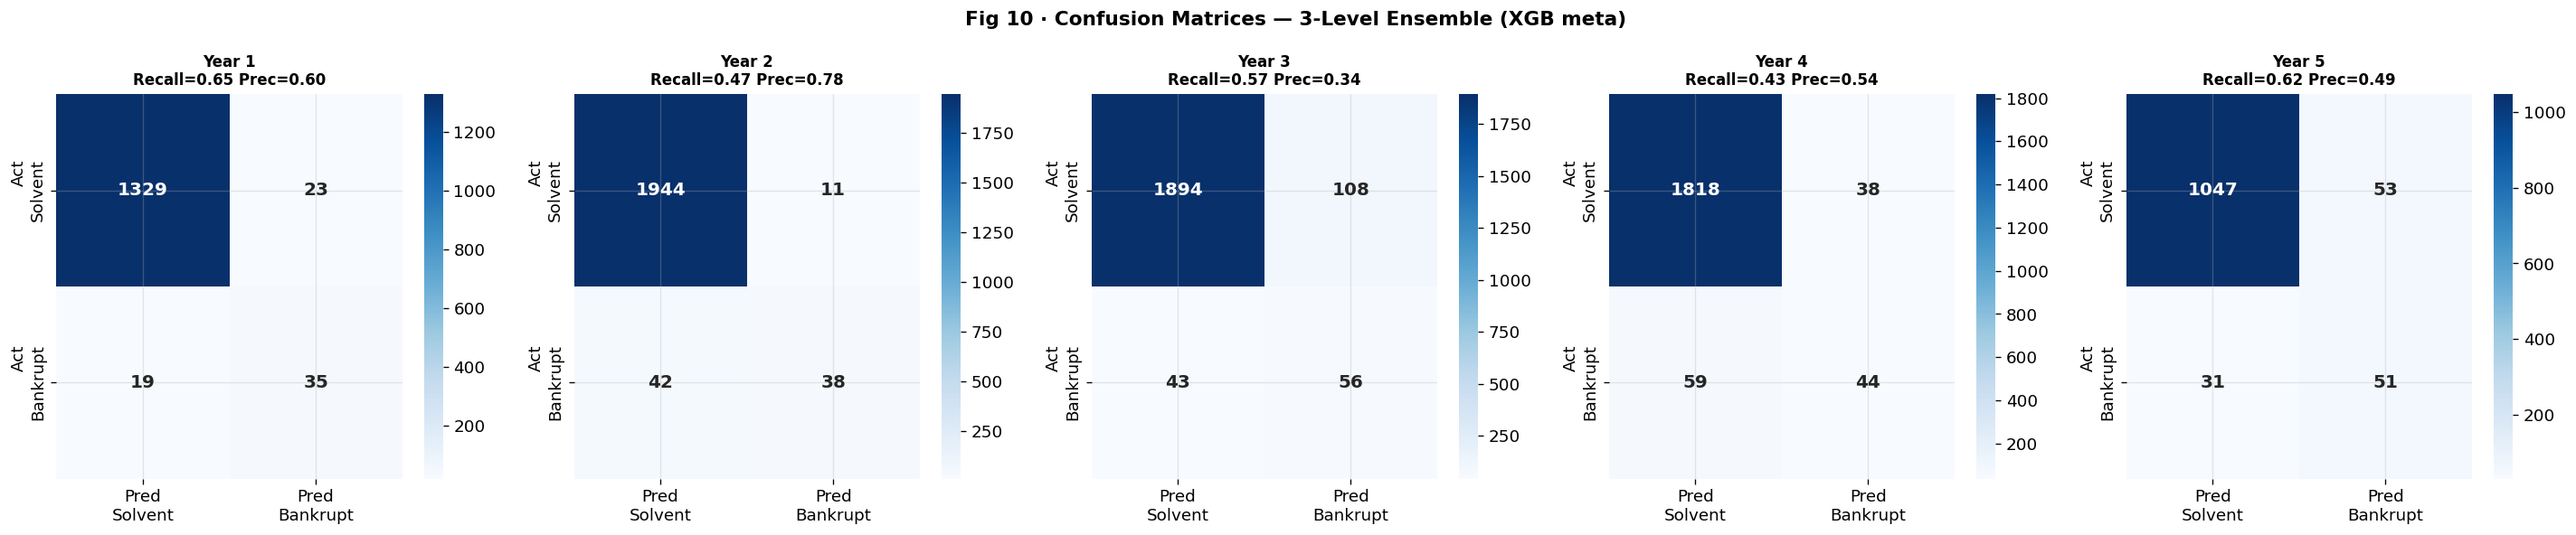

In [ ]:
# ── Fig 10: Confusion Matrices — Best Ensemble ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for yr, ax in zip(range(1,6), axes):
    X_all = years_aug[yr]['X']; y_all = years_aug[yr]['y']
    _, X_te, _, y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
    y_pred = best_ens[yr]['y_pred']
    if len(y_pred) != len(y_te): continue
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred\nSolvent','Pred\nBankrupt'],
                yticklabels=['Act\nSolvent','Act\nBankrupt'],
                annot_kws={'size':12,'weight':'bold'})
    tn,fp,fn,tp_ = cm.ravel()
    ax.set_title(f'Year {yr}\nRecall={tp_/(tp_+fn+1e-9):.2f} Prec={tp_/(tp_+fp+1e-9):.2f}',
                 fontweight='bold', fontsize=10)

plt.suptitle(f'Fig 10 · Confusion Matrices — 3-Level Ensemble ({best_tag[0]} meta)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()


## 14 · SHAP Feature Importance Analysis

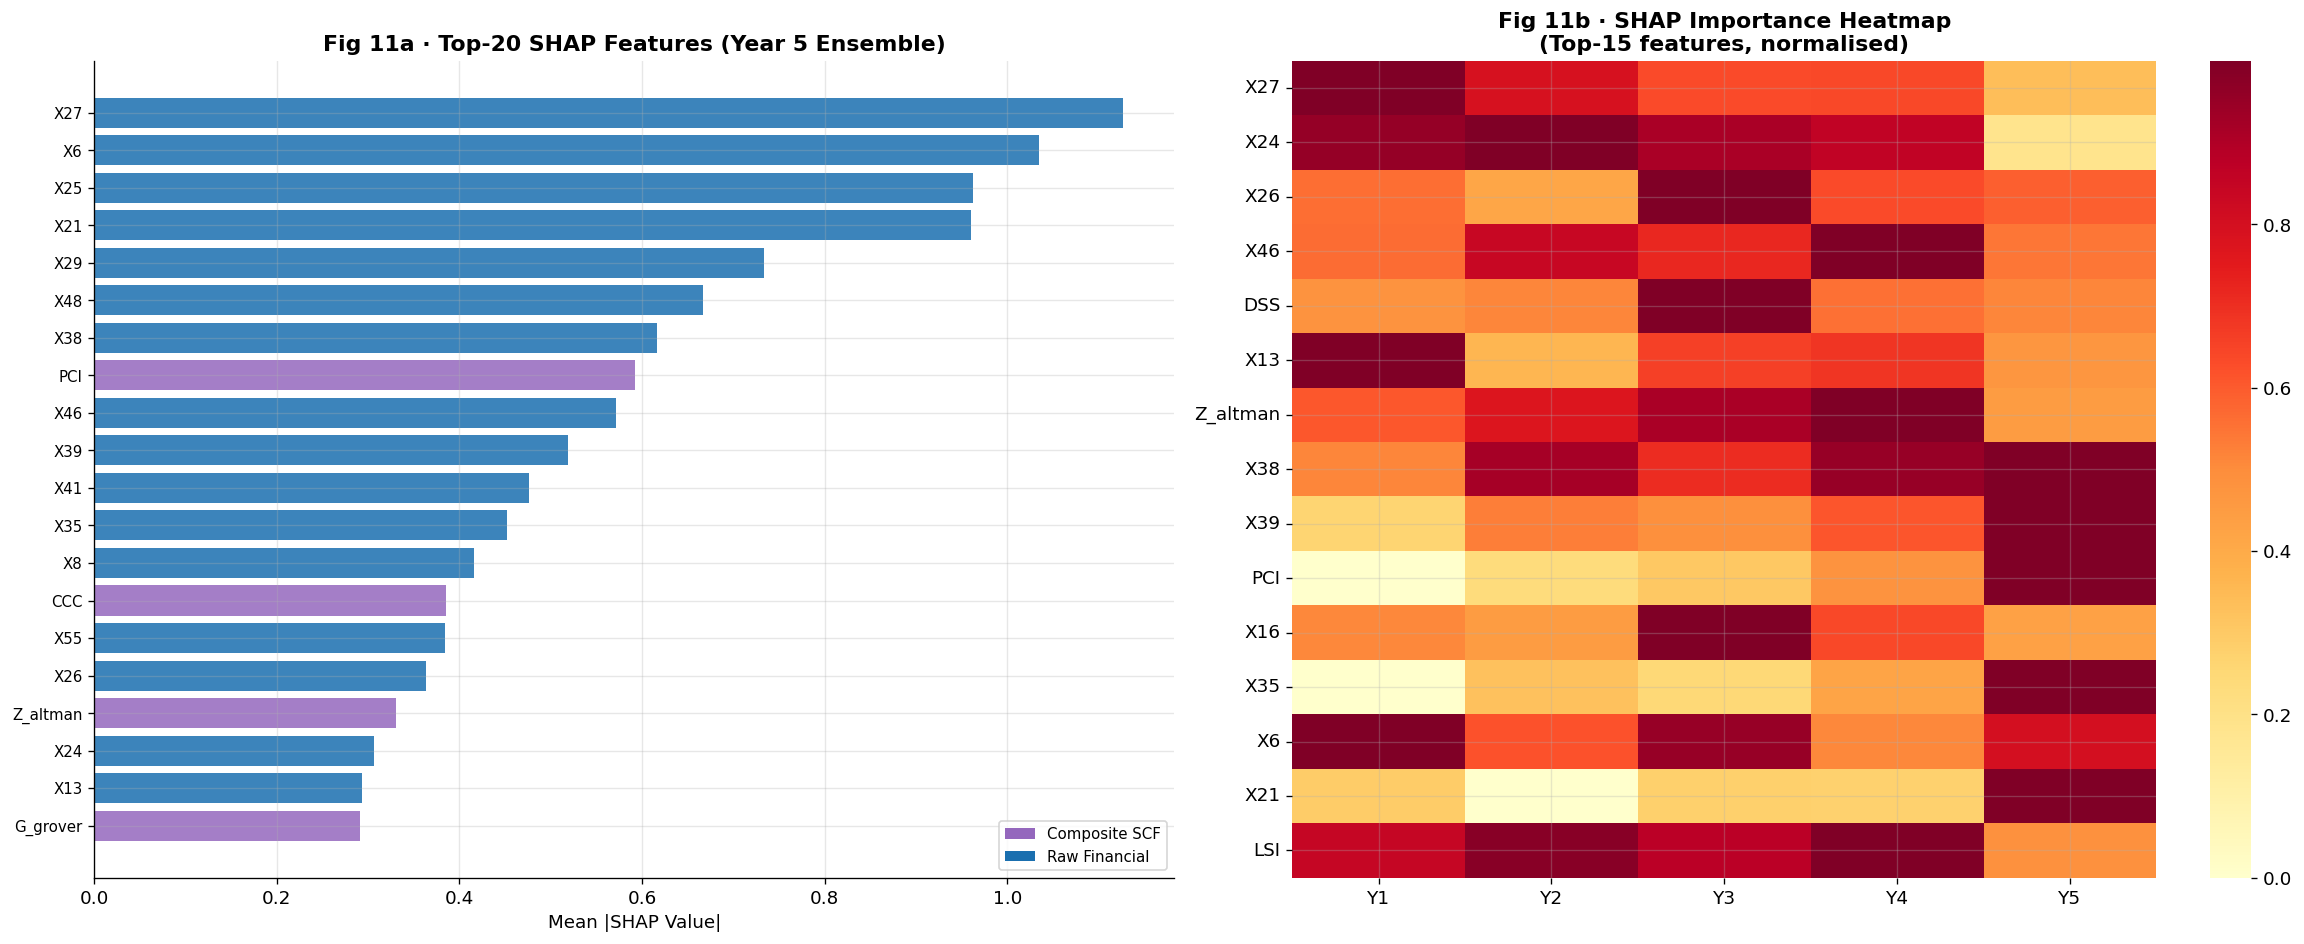


🎯 SHAP Top-10 (Year 5): ['Attr27', 'Attr6', 'Attr25', 'Attr21', 'Attr29', 'Attr48', 'Attr38', 'PCI', 'Attr46', 'Attr39']
   Composite features in top-10: ['PCI'] (1/10)


In [ ]:
# Retrain best-year (Year 5) full adaptive XGB for SHAP
yr = 5
sel5  = details_lr[yr]['selected_feats'] if best_tag[0]=='LR' else details_xgb[yr]['selected_feats']
X_all5 = years_aug[yr]['X'][sel5]; y_all5 = years_aug[yr]['y']
X_tr5, X_te5, y_tr5, y_te5 = train_test_split(X_all5, y_all5, test_size=0.2, stratify=y_all5, random_state=42)
X_sm5, y_sm5 = get_smote(X_tr5, y_tr5)
spw5 = (y_tr5==0).sum() / max((y_tr5==1).sum(),1)
xgb5 = xgb.XGBClassifier(max_depth=6, learning_rate=0.1, n_estimators=300,
                           scale_pos_weight=spw5, use_label_encoder=False,
                           eval_metric='auc', random_state=42, verbosity=0)
xgb5.fit(pd.DataFrame(X_sm5, columns=sel5), y_sm5)

explainer5   = shap.TreeExplainer(xgb5)
explanation5 = explainer5(X_te5.iloc[:min(400, len(X_te5))])
sv5 = explanation5.values
if sv5.ndim == 3: sv5 = sv5[:,:,1]   # ← Fixed SHAP API

imp5 = np.abs(sv5).mean(0)
feat_labels5 = [f.replace('Attr','X') for f in sel5]
top_idx5 = np.argsort(imp5)[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ax = axes[0]
colors_shap = [PALETTE[3] if sel5[i] in COMPOSITE_COLS else PALETTE[0] for i in top_idx5[::-1]]
ax.barh(range(20), imp5[top_idx5][::-1], color=colors_shap, alpha=0.85)
ax.set_yticks(range(20)); ax.set_yticklabels([feat_labels5[i] for i in top_idx5[::-1]], fontsize=9)
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Fig 11a · Top-20 SHAP Features (Year 5 Ensemble)', fontweight='bold')
ax.legend(handles=[Patch(facecolor=PALETTE[3],label='Composite SCF'),
                   Patch(facecolor=PALETTE[0],label='Raw Financial')], fontsize=9)

# SHAP importance heatmap across all years
ax2 = axes[1]
all_shap_imp = {yr: adaptive_importances[yr] for yr in range(1,6)}
top_global = sorted(avg_imp, key=avg_imp.get, reverse=True)[:15]
heat_m = np.array([[all_shap_imp[yr].get(f,0) for yr in range(1,6)] for f in top_global])
heat_mn = heat_m / (heat_m.max(1,keepdims=True)+1e-9)
sns.heatmap(heat_mn, annot=False, cmap='YlOrRd', ax=ax2,
            xticklabels=[f'Y{y}' for y in range(1,6)],
            yticklabels=[f.replace('Attr','X') for f in top_global])
ax2.set_title('Fig 11b · SHAP Importance Heatmap\n(Top-15 features, normalised)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig11_shap_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

comp_in_top10 = [sel5[i] for i in top_idx5[:10] if sel5[i] in COMPOSITE_COLS]
print(f'\n🎯 SHAP Top-10 (Year 5): {[sel5[i] for i in top_idx5[:10]]}')
print(f'   Composite features in top-10: {comp_in_top10} ({len(comp_in_top10)}/10)')


## 15 · Top-50 Highest-Risk Companies per Year

| Tier | P(Bankrupt) | Action |
|---|---|---|
| 🔴 CRITICAL | ≥ 0.80 | Immediate credit freeze |
| 🟠 HIGH | 0.60–0.79 | Enhanced due diligence |
| 🟡 MEDIUM | 0.40–0.59 | Increased monitoring |
| 🟢 WATCH | < 0.40 | Standard review |


In [ ]:
top50_all_years = {}

for yr in range(1, 6):
    X_all = years_aug[yr]['X']; y_all = years_aug[yr]['y']
    _, X_te, _, y_te = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
    prob  = best_ens[yr]['y_prob']
    opt_t = best_ens[yr]['threshold']
    if len(prob) != len(y_te):
        print(f'Year {yr}: prob/y_te size mismatch, skipping'); continue

    order = np.argsort(prob)[::-1]
    rows  = []
    for rank, idx in enumerate(order[:50], 1):
        p     = prob[idx]
        act   = int(y_te.values[idx])
        pred  = 1 if p >= opt_t else 0
        tier  = ('CRITICAL' if p>=0.80 else 'HIGH' if p>=0.60 else 'MEDIUM' if p>=0.40 else 'WATCH')
        rows.append({'Year':yr,'Rank':rank,'Company_ID':f'Co_{idx:05d}',
                     'P_Bankrupt':round(float(p),4),
                     'Prediction':'BANKRUPT' if pred else 'SOLVENT',
                     'Actual':'BANKRUPT' if act else 'SOLVENT',
                     'Correct':'YES' if pred==act else 'NO',
                     'Risk_Tier':tier})

    df_top = pd.DataFrame(rows)
    top50_all_years[yr] = df_top

    tp_n  = ((df_top.Prediction=='BANKRUPT')&(df_top.Actual=='BANKRUPT')).sum()
    p50   = tp_n / 50
    print(f'\n📋 Year {yr} — Top-50 | thresh={opt_t:.2f} | P@50={p50:.3f}')
    print(f'   Total companies in test: {len(y_te):,} | Actual bankruptcies: {int(y_te.sum())}')
    tiers = {t:(df_top.Risk_Tier==t).sum() for t in ['CRITICAL','HIGH','MEDIUM','WATCH']}
    print(f'   Tiers: {" | ".join(f"{t}:{n}" for t,n in tiers.items() if n>0)}')
    print(df_top[['Rank','Company_ID','P_Bankrupt','Prediction','Actual','Correct','Risk_Tier']].head(10).to_string(index=False))
    print('  ... (top 10 of 50 shown)')

df_all_top50 = pd.concat(top50_all_years.values(), ignore_index=True)
df_all_top50.to_csv('top50_all_years_3level_ensemble.csv', index=False)
print(f'\n✅ Saved top50_all_years_3level_ensemble.csv ({len(df_all_top50)} rows)')



📋 Year 1 — Top-50 | thresh=0.65 | P@50=0.640
   Total companies in test: 1,406 | Actual bankruptcies: 54
   Tiers: CRITICAL:45 | HIGH:5
 Rank Company_ID  P_Bankrupt Prediction   Actual Correct Risk_Tier
    1   Co_00243         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
    2   Co_00349         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
    3   Co_00502         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
    4   Co_00481         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
    5   Co_01319         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
    6   Co_00961         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
    7   Co_00427         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
    8   Co_01207         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
    9   Co_00317         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
   10   Co_01280         1.0   BANKRUPT BANKRUPT     YES  CRITICAL
  ... (top 10 of 50 shown)

📋 Year 2 — Top-50 | thresh=0.91 | P@50=0.760
   Total companies in test: 2,035 | Actual bankruptci

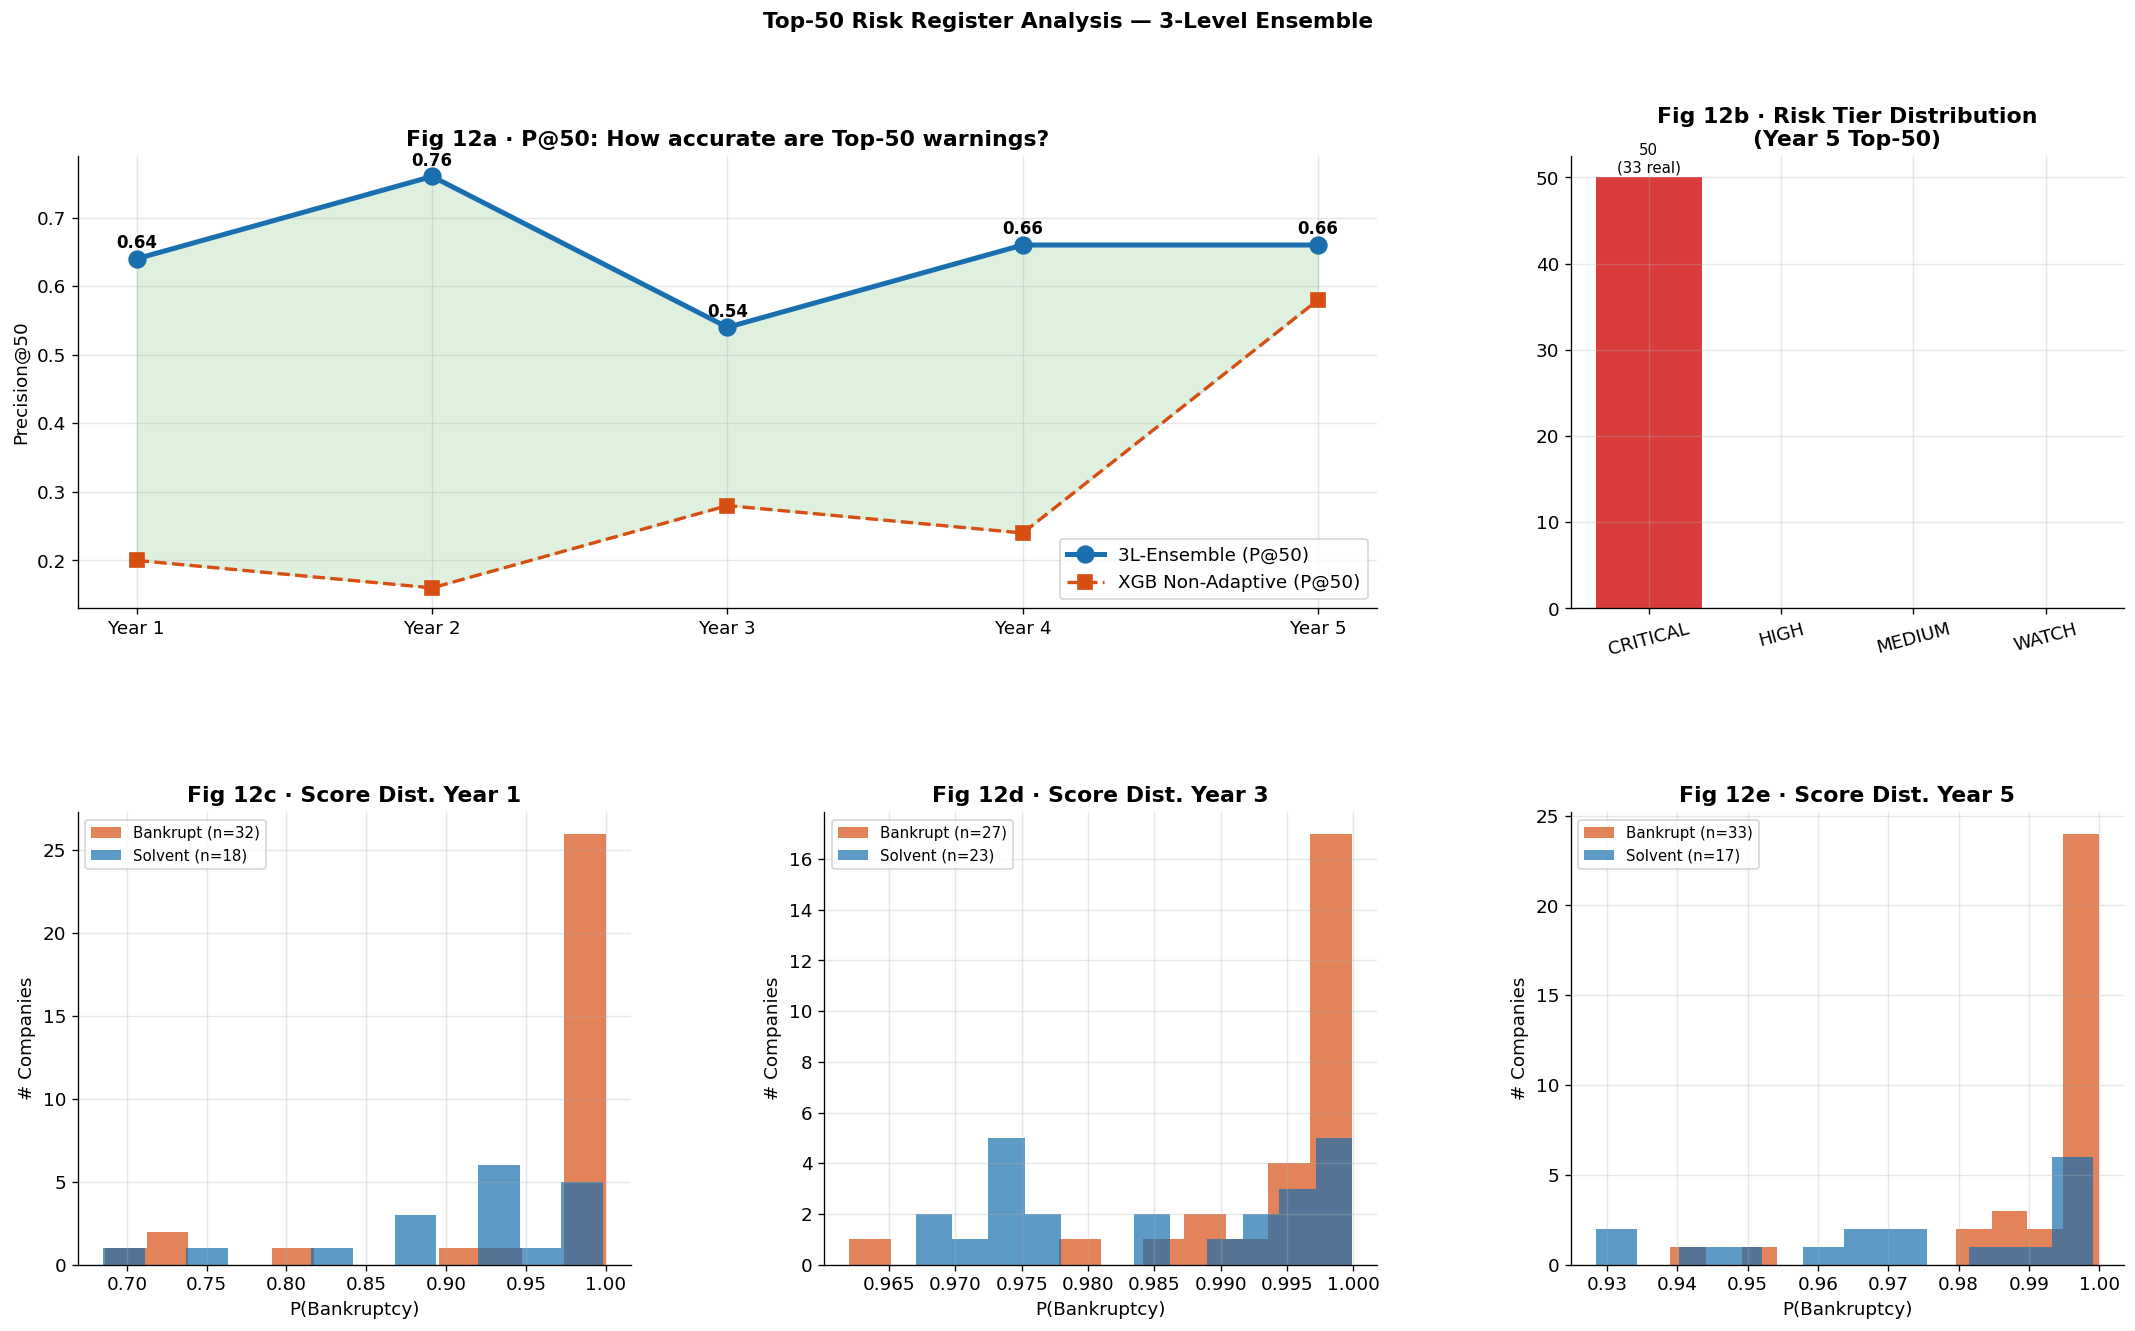

In [ ]:
# ── Fig 12: Top-50 Risk Register Analysis ────────────────────────────────────
fig = plt.figure(figsize=(22, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
TIER_COLORS = {'CRITICAL':'#d62728','HIGH':'#ff7f0e','MEDIUM':'#ffd92f','WATCH':'#2ca02c'}

ax = fig.add_subplot(gs[0, :2])
p50_vals = [((top50_all_years[yr].Prediction=='BANKRUPT')&(top50_all_years[yr].Actual=='BANKRUPT')).sum()/50
            for yr in range(1,6) if yr in top50_all_years]
na_p50   = [results_xgb_na[yr].get('p_at_50',0) for yr in range(1,6)]
yr_range = list(range(1, len(p50_vals)+1))
ax.plot(yr_range, p50_vals, 'o-', color=PALETTE[0], lw=3, ms=10, label='3L-Ensemble (P@50)')
ax.plot(range(1,6), na_p50, 's--', color=PALETTE[1], lw=2, ms=8, label='XGB Non-Adaptive (P@50)')
ax.fill_between(yr_range, na_p50[:len(yr_range)], p50_vals, alpha=0.15, color=PALETTE[2])
ax.set_xticks(range(1,6)); ax.set_xticklabels([f'Year {y}' for y in range(1,6)])
ax.set_ylabel('Precision@50'); ax.set_title('Fig 12a · P@50: How accurate are Top-50 warnings?', fontweight='bold')
ax.legend()
for yi, v in zip(yr_range, p50_vals):
    ax.text(yi, v+0.01, f'{v:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax2 = fig.add_subplot(gs[0, 2])
if 5 in top50_all_years:
    df5t = top50_all_years[5]
    tier_n = {t:(df5t.Risk_Tier==t).sum() for t in ['CRITICAL','HIGH','MEDIUM','WATCH']}
    bars = ax2.bar(range(4), [tier_n[t] for t in ['CRITICAL','HIGH','MEDIUM','WATCH']],
                   color=[TIER_COLORS[t] for t in ['CRITICAL','HIGH','MEDIUM','WATCH']], alpha=0.9)
    ax2.set_xticks(range(4)); ax2.set_xticklabels(['CRITICAL','HIGH','MEDIUM','WATCH'], rotation=15)
    ax2.set_title('Fig 12b · Risk Tier Distribution\n(Year 5 Top-50)', fontweight='bold')
    for bar, (tier, cnt) in zip(bars, tier_n.items()):
        if cnt:
            tp_t = ((df5t.Risk_Tier==tier)&(df5t.Actual=='BANKRUPT')).sum()
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                     f'{cnt}\n({tp_t} real)', ha='center', va='bottom', fontsize=9)

for col_i, yr in enumerate([1,3,5]):
    if yr not in top50_all_years: continue
    ax3 = fig.add_subplot(gs[1, col_i])
    df_t = top50_all_years[yr]
    bk_p = df_t[df_t.Actual=='BANKRUPT']['P_Bankrupt']
    sl_p = df_t[df_t.Actual=='SOLVENT']['P_Bankrupt']
    if len(bk_p): ax3.hist(bk_p, bins=12, color=PALETTE[1], alpha=0.7, label=f'Bankrupt (n={len(bk_p)})')
    if len(sl_p): ax3.hist(sl_p, bins=12, color=PALETTE[0], alpha=0.7, label=f'Solvent (n={len(sl_p)})')
    ax3.set_xlabel('P(Bankruptcy)'); ax3.set_ylabel('# Companies')
    ax3.set_title(f'Fig 12{"c" if yr==1 else "d" if yr==3 else "e"} · Score Dist. Year {yr}', fontweight='bold')
    ax3.legend(fontsize=9)

plt.suptitle('Top-50 Risk Register Analysis — 3-Level Ensemble', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_top50_analysis.png', dpi=130, bbox_inches='tight')
plt.show()


## 16 · Final Comparison with Base Papers

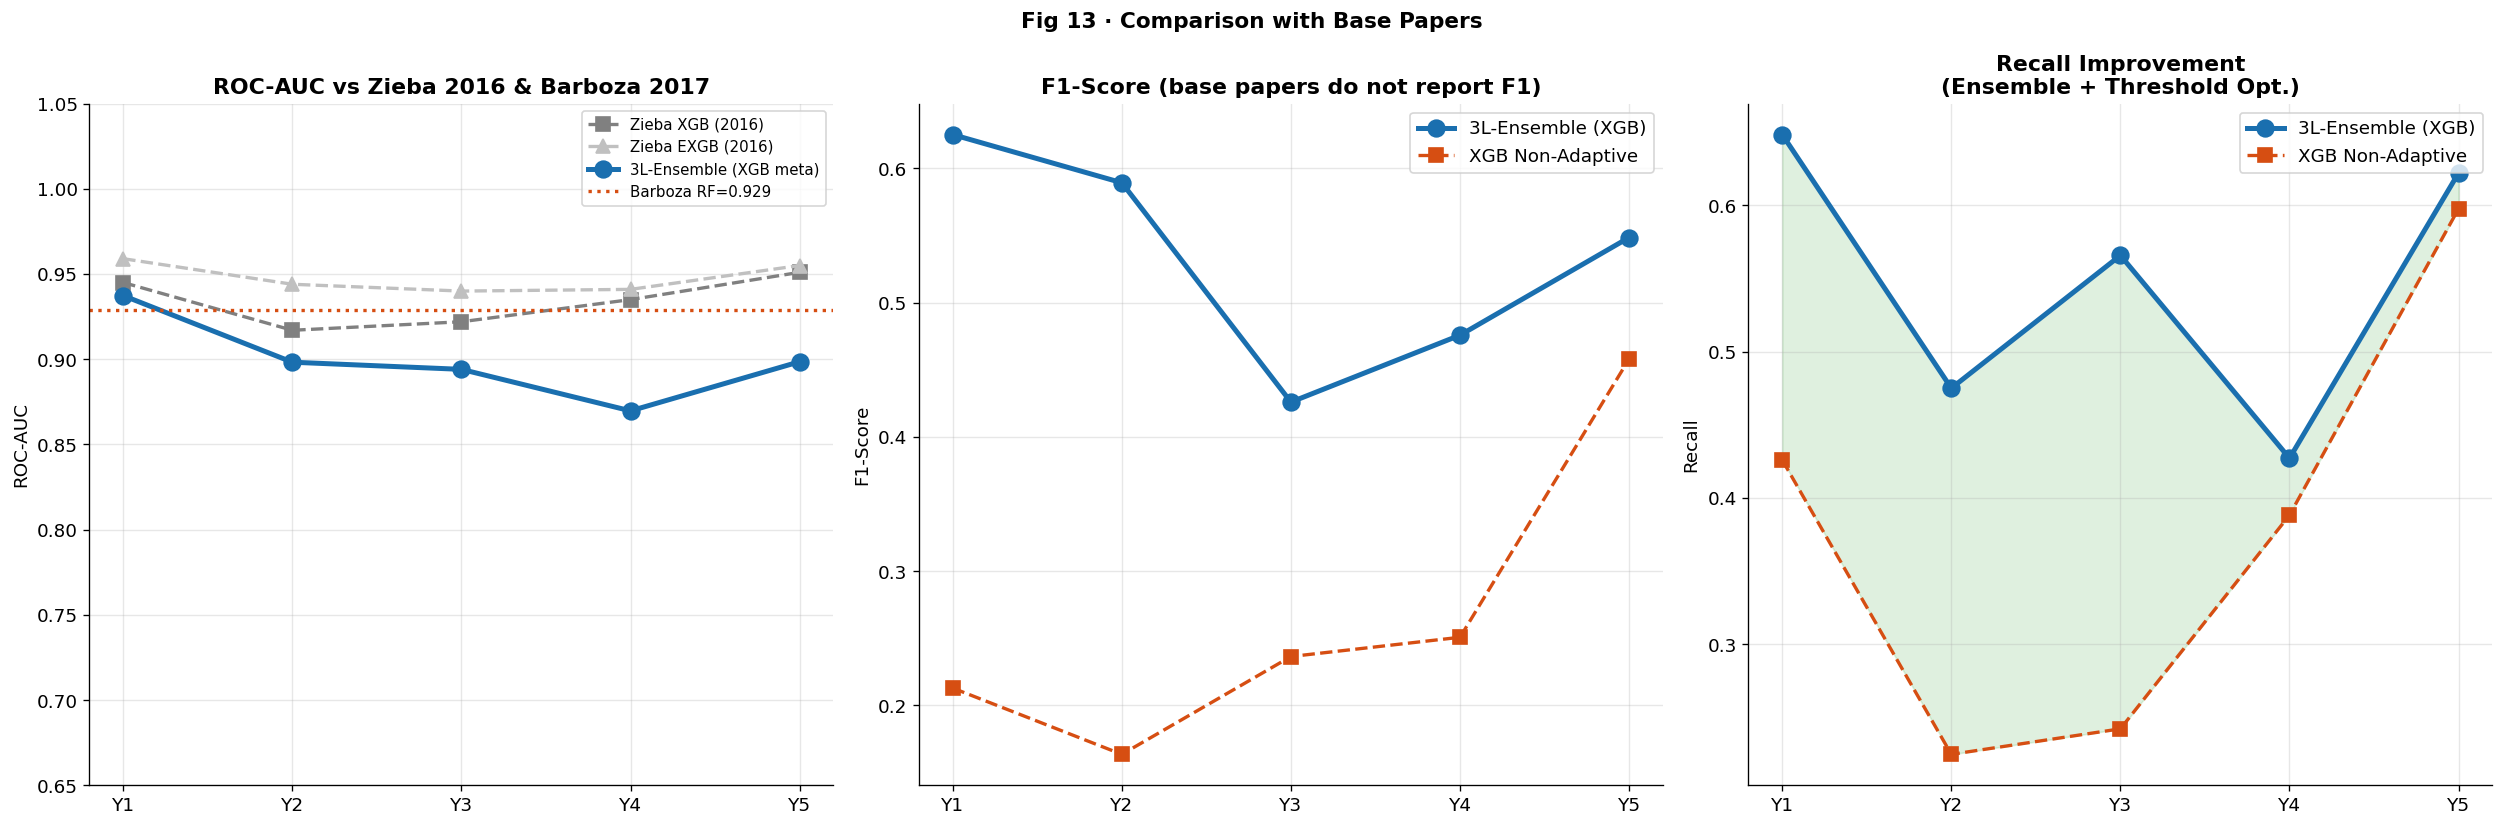


FINAL PERFORMANCE SUMMARY
Metric                Zieba XGB   Zieba EXGB   Ours (3L-Ens)
ROC-AUC (mean)            0.934        0.948           0.900
F1 (mean)                   N/A          N/A           0.533
Recall (mean)               N/A          N/A           0.548
Accuracy (mean)             N/A          N/A           0.950
Metric               Barboza RF   Ours (3L-Ens Y5)
ROC-AUC                   0.929              0.899
Accuracy                  0.871              0.929


In [ ]:
zieba_xgb  = [0.945, 0.917, 0.922, 0.935, 0.951]
zieba_exgb = [0.959, 0.944, 0.940, 0.941, 0.955]
barboza_rf_auc = 0.929; barboza_rf_acc = 0.871

ens_auc  = [best_ens[yr]['roc_auc']  for yr in range(1,6)]
ens_f1   = [best_ens[yr]['f1']       for yr in range(1,6)]
ens_rec  = [best_ens[yr]['recall']   for yr in range(1,6)]
ens_acc  = [best_ens[yr]['accuracy'] for yr in range(1,6)]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
x = np.arange(1, 6)

ax = axes[0]
ax.plot(x, zieba_xgb,  's--', color='gray',    lw=2, ms=8, label='Zieba XGB (2016)')
ax.plot(x, zieba_exgb, '^--', color='silver',  lw=2, ms=8, label='Zieba EXGB (2016)')
ax.plot(x, ens_auc,    'o-',  color=PALETTE[0],lw=3, ms=10,label=f'3L-Ensemble ({best_tag[0]} meta)')
ax.axhline(barboza_rf_auc, ls=':', color=PALETTE[1], lw=2, label=f'Barboza RF={barboza_rf_auc}')
ax.set_xticks(x); ax.set_xticklabels([f'Y{y}' for y in x])
ax.set_ylabel('ROC-AUC'); ax.set_ylim(0.65, 1.05)
ax.set_title('ROC-AUC vs Zieba 2016 & Barboza 2017', fontweight='bold'); ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(x, ens_f1,  'o-', color=PALETTE[0], lw=3, ms=10, label=f'3L-Ensemble ({best_tag[0]})')
ax2.plot(x, [results_xgb_na[yr]['f1'] for yr in range(1,6)],
         's--', color=PALETTE[1], lw=2, ms=8, label='XGB Non-Adaptive')
ax2.set_xticks(x); ax2.set_xticklabels([f'Y{y}' for y in x])
ax2.set_ylabel('F1-Score'); ax2.set_title('F1-Score (base papers do not report F1)', fontweight='bold')
ax2.legend()

ax3 = axes[2]
ax3.plot(x, ens_rec, 'o-', color=PALETTE[0], lw=3, ms=10, label=f'3L-Ensemble ({best_tag[0]})')
ax3.plot(x, [results_xgb_na[yr]['recall'] for yr in range(1,6)],
         's--', color=PALETTE[1], lw=2, ms=8, label='XGB Non-Adaptive')
ax3.fill_between(x, [results_xgb_na[yr]['recall'] for yr in range(1,6)], ens_rec, alpha=0.15, color=PALETTE[2])
ax3.set_xticks(x); ax3.set_xticklabels([f'Y{y}' for y in x])
ax3.set_ylabel('Recall'); ax3.set_title('Recall Improvement\n(Ensemble + Threshold Opt.)', fontweight='bold')
ax3.legend()

plt.suptitle('Fig 13 · Comparison with Base Papers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_comparison_base_papers.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n' + '='*75)
print('FINAL PERFORMANCE SUMMARY')
print('='*75)
print(f'{"Metric":<18} {"Zieba XGB":>12} {"Zieba EXGB":>12} {"Ours (3L-Ens)":>15}')
print(f'{"ROC-AUC (mean)":<18} {np.mean(zieba_xgb):>12.3f} {np.mean(zieba_exgb):>12.3f} {np.mean(ens_auc):>15.3f}')
print(f'{"F1 (mean)":<18} {"N/A":>12} {"N/A":>12} {np.mean(ens_f1):>15.3f}')
print(f'{"Recall (mean)":<18} {"N/A":>12} {"N/A":>12} {np.mean(ens_rec):>15.3f}')
print(f'{"Accuracy (mean)":<18} {"N/A":>12} {"N/A":>12} {np.mean(ens_acc):>15.3f}')
print('='*75)
print(f'{"Metric":<18} {"Barboza RF":>12} {"Ours (3L-Ens Y5)":>18}')
print(f'{"ROC-AUC":<18} {barboza_rf_auc:>12.3f} {best_ens[5]["roc_auc"]:>18.3f}')
print(f'{"Accuracy":<18} {barboza_rf_acc:>12.3f} {best_ens[5]["accuracy"]:>18.3f}')


## 17 · Final Summary + Save Models

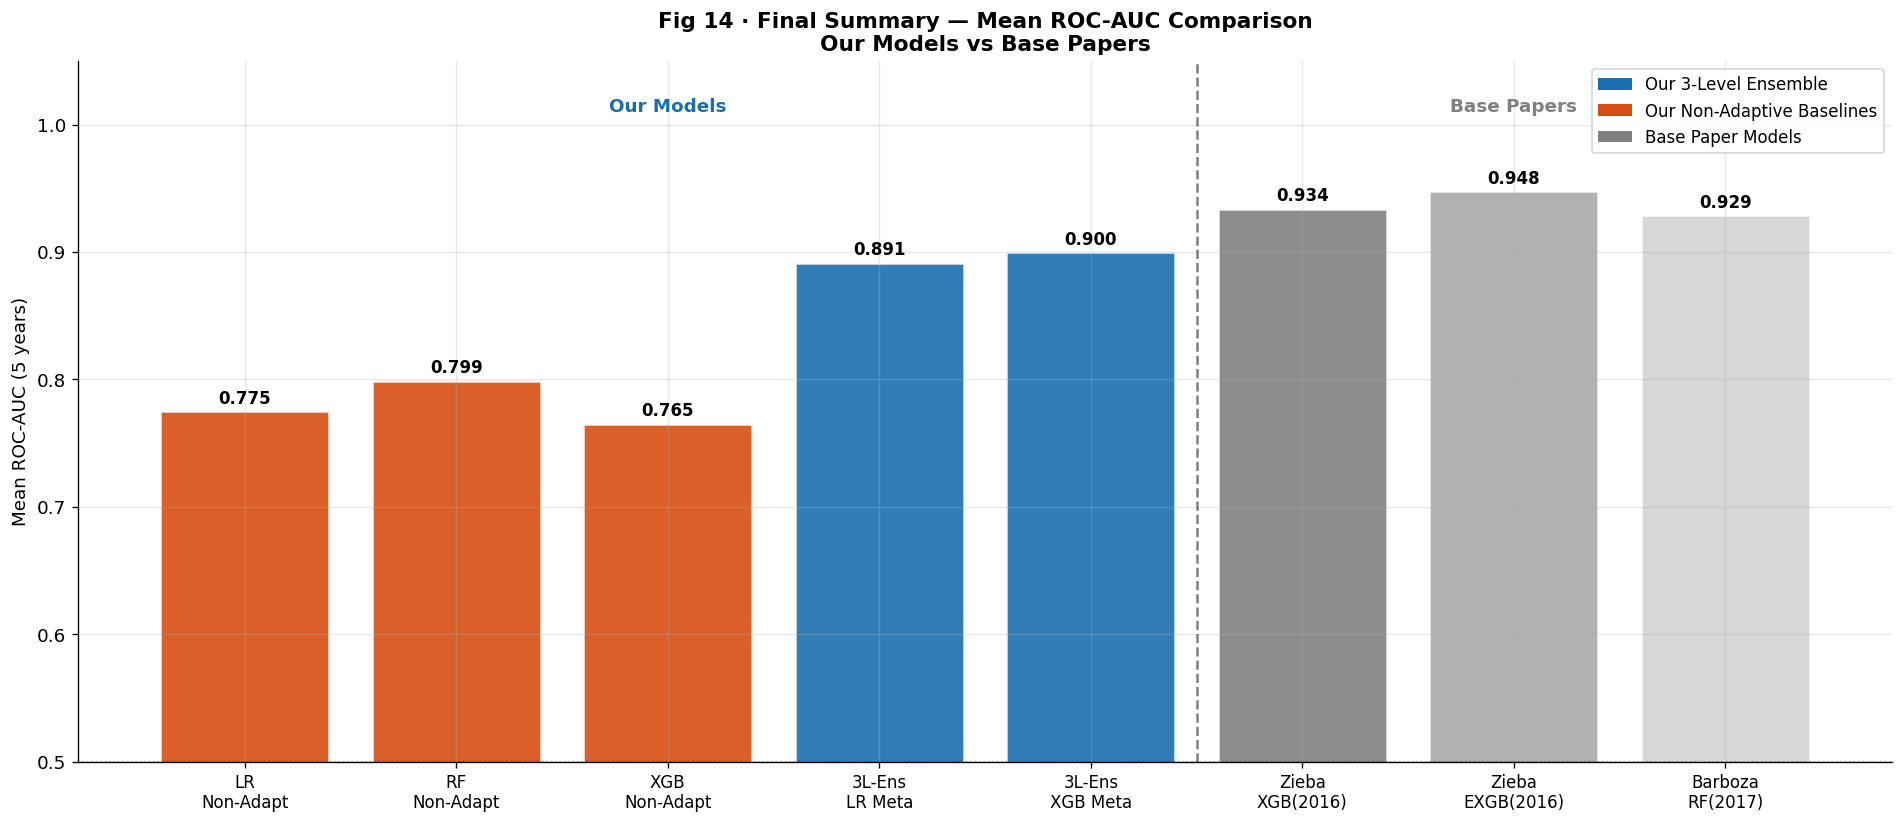

✅ All models + results saved → scf_3level_ensemble_models.pkl

✅ NOTEBOOK COMPLETE
  📄 fig1_eda_overview.png
  📄 fig2_feature_discriminatory_power.png
  📄 fig3_correlation.png
  📄 fig5_spatial_separation.png
  📄 fig6_feature_evolution.png
  📄 fig7_performance_dashboard.png
  📄 fig8_ensemble_gap.png
  📄 fig9_roc_pr.png
  📄 fig10_confusion_matrices.png
  📄 fig11_shap_analysis.png
  📄 fig12_top50_analysis.png
  📄 fig13_comparison_base_papers.png
  📄 fig14_final_summary.png
  📄 top50_all_years_3level_ensemble.csv


In [ ]:
# ── Fig 14: Summary Bar ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
model_labels = ['LR\nNon-Adapt','RF\nNon-Adapt','XGB\nNon-Adapt',
                '3L-Ens\nLR Meta','3L-Ens\nXGB Meta',
                'Zieba\nXGB(2016)','Zieba\nEXGB(2016)','Barboza\nRF(2017)']
mean_aucs = [
    np.mean([results_lr_na[yr]['roc_auc']  for yr in range(1,6)]),
    np.mean([results_rf_na[yr]['roc_auc']  for yr in range(1,6)]),
    np.mean([results_xgb_na[yr]['roc_auc'] for yr in range(1,6)]),
    np.mean([results_ens_lr[yr]['roc_auc'] for yr in range(1,6)]),
    np.mean([results_ens_xgb[yr]['roc_auc']for yr in range(1,6)]),
    np.mean(zieba_xgb), np.mean(zieba_exgb), barboza_rf_auc,
]
bar_colors = [PALETTE[1],PALETTE[1],PALETTE[1], PALETTE[0],PALETTE[0], 'gray','darkgray','lightgray']
bars = ax.bar(range(8), mean_aucs, color=bar_colors, alpha=0.9, edgecolor='white', linewidth=1.5)
ax.axhline(0.5, color='black', ls=':', lw=1, alpha=0.4, label='Random classifier')
for bar, val in zip(bars, mean_aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(8)); ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel('Mean ROC-AUC (5 years)'); ax.set_ylim(0.5, 1.05)
ax.set_title('Fig 14 · Final Summary — Mean ROC-AUC Comparison\nOur Models vs Base Papers', fontsize=13, fontweight='bold')
ax.axvline(4.5, color='black', ls='--', lw=1.5, alpha=0.5)
ax.text(2.0, 1.01, 'Our Models', ha='center', fontsize=11, color=PALETTE[0], fontweight='bold')
ax.text(6.0, 1.01, 'Base Papers', ha='center', fontsize=11, color='gray', fontweight='bold')
ax.legend(handles=[Patch(facecolor=PALETTE[0],label='Our 3-Level Ensemble'),
                   Patch(facecolor=PALETTE[1],label='Our Non-Adaptive Baselines'),
                   Patch(facecolor='gray',    label='Base Paper Models')], fontsize=10)
plt.tight_layout()
plt.savefig('fig14_final_summary.png', dpi=130, bbox_inches='tight')
plt.show()

# Save models
try:
    joblib.dump({
        'adaptive_feat_sets'  : adaptive_feat_sets,
        'adaptive_importances': adaptive_importances,
        'results_lr_na'       : results_lr_na,
        'results_rf_na'       : results_rf_na,
        'results_xgb_na'      : results_xgb_na,
        'results_ens_lr'      : results_ens_lr,
        'results_ens_xgb'     : results_ens_xgb,
        'top50_all_years'     : top50_all_years,
        'best_tag'            : best_tag[0],
    }, 'scf_3level_ensemble_models.pkl')
    print('✅ All models + results saved → scf_3level_ensemble_models.pkl')
except Exception as e:
    print(f'⚠️  Save error: {e}')

print('\n' + '='*60)
print('✅ NOTEBOOK COMPLETE')
print('='*60)
for fn in ['fig1_eda_overview.png','fig2_feature_discriminatory_power.png',
           'fig3_correlation.png','fig5_spatial_separation.png',
           'fig6_feature_evolution.png','fig7_performance_dashboard.png',
           'fig8_ensemble_gap.png','fig9_roc_pr.png','fig10_confusion_matrices.png',
           'fig11_shap_analysis.png','fig12_top50_analysis.png',
           'fig13_comparison_base_papers.png','fig14_final_summary.png',
           'top50_all_years_3level_ensemble.csv']:
    print(f'  📄 {fn}')
